# Improved ΔQ Model for Linear Leios EB Diffusion

*Self-contained interactive analysis notebook.*  Mirrors `report.md`; the code
is the same as `analysis.py` but inlined so the notebook is standalone and
plots render inline.  Key parameter blocks are marked `# === edit ===` — change
them and re-run the cell to explore the numbers.

## 1. Executive Summary

This notebook presents a corrected and extended ΔQ analysis of Endorser Block
(EB) diffusion in Linear Leios.  It fixes three structural bugs in the
previous analysis, uses a proper numerical (discretized CDF) backend,
re-derives the per-transaction timing constants from the empirical
`block-edf.csv` dataset, and instantiates the model under **two TCP
congestion-control models** — **Reno** (via the Mathis equation) and **CUBIC**
— to bound the network-induced sensitivity.

**Bottom line.** Under the 1-hop approximation and the Praos paper's RTT
values, the 12 MB CIP target is robustly feasible under both throughput
models — the Mathis-vs-CUBIC distinction is immaterial at every tested size.
$P_\text{cert}$ stays at the Praos cap of $\approx 0.497$ across the full
0–12 MB sweep under both models.

The certification probability is capped at $\approx 0.497$ by the Praos
leader schedule whenever quorum is met (independent of throughput model).
The **1-hop approximation is the remaining load-bearing assumption**: under
total pre-diffusion failure the effective $P_\text{cert}$ collapses to ≈ 0
under either throughput model at 12 MB.


## 2. Protocol Recap

Linear Leios extends Ouroboros Praos by adding Endorser Blocks (EBs).  The
relevant timing pipeline (one round) is:

```
  slot:  |---L_hdr---|---L_hdr---|---L_hdr---|---L_vote---|---L_diff---|
             (1) RB    (2) EB      (3) cert    voting wdw   EB body
             header    header      header                   + cert
             diffuses  diffuses    diffuses                 diffuses
  total: 3×L_hdr + L_vote + L_diff = 3+4+7 = 14 slots
```

An EB is certified when ≥ τ·m = 75% × 600 = 450 committee members vote for
it within the voting window (7 slots from round start).  If certified, the
next ranking block (RB) carries the EB certificate rather than transactions.

**RB structure (critical):** An RB contains *either* an EB certificate
(certRB) *or* transactions (txRB), never both simultaneously.  The prior
analysis forced both paths in parallel — this is incorrect.


## 4. Model Description

### 4.1 Numerical Backend

Discretized CDF on a fixed time grid.

- Grid: $N = 4000$ points, $\Delta t = 10$ ms, $T_\text{max} = 40$ s
- Sequential composition: FFT-based convolution — $O(N \log N)$
- All other operators (last-to-finish, first-to-finish, choice): pointwise

This is equivalent in design to the `Discretized` Haskell module proposed in
the `deltaq/mw/approx` branch.  The 10 ms resolution is sufficient for this
analysis (timing differences relevant to the protocol are on the order of
100 ms or larger).


In [1]:
%matplotlib inline
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

# ---------------------------------------------------------------------------
# GLOBAL GRID PARAMETERS
# ---------------------------------------------------------------------------

T_MAX = 40.0  # seconds – covers all realistic completion times
N = 4000  # number of grid points
DT = T_MAX / N  # = 0.010 s per step  (10 ms resolution)

TIMES = np.arange(1, N + 1) * DT  # [DT, 2DT, ..., T_MAX]


# ---------------------------------------------------------------------------
# DISCRETIZED CDF PRIMITIVES
# ---------------------------------------------------------------------------


def cdf_never() -> np.ndarray:
    """Outcome that never finishes: CDF = 0 everywhere."""
    return np.zeros(N)


def cdf_wait(t: float) -> np.ndarray:
    """Deterministic wait: P(X <= t') = 1 if t' >= t, else 0."""
    return np.where(TIMES >= t, 1.0, 0.0)


def cdf_uniform(a: float, b: float) -> np.ndarray:
    """Uniform distribution on [a, b]."""
    if a >= b:
        return cdf_wait(a)
    return np.clip((TIMES - a) / (b - a), 0.0, 1.0)


def cdf_choice(p: float, cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Probabilistic choice: p * cdf1 + (1-p) * cdf2."""
    return p * cdf1 + (1.0 - p) * cdf2


def cdf_choices(weighted: list) -> np.ndarray:
    """choices [(w1, cdf1), (w2, cdf2), ...]  (weights unnormalised)."""
    total = sum(w for w, _ in weighted)
    result = np.zeros(N)
    for w, cdf in weighted:
        result += (w / total) * cdf
    return result


def _to_pdf(cdf: np.ndarray) -> np.ndarray:
    """CDF → PDF (first differences)."""
    pdf = np.empty(N)
    pdf[0] = cdf[0]
    pdf[1:] = np.diff(cdf)
    return pdf


def cdf_sequential(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Sequential composition (convolution of PDFs) via FFT."""
    pdf1 = _to_pdf(cdf1)
    pdf2 = _to_pdf(cdf2)
    n2 = 2 * N
    conv = np.fft.irfft(np.fft.rfft(pdf1, n2) * np.fft.rfft(pdf2, n2), n2)[:N]
    conv = np.maximum(conv, 0.0)  # clamp FFT artefacts
    result = np.cumsum(conv)
    return np.minimum(result, 1.0)  # clamp to [0, 1]


def cdf_last_to_finish(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Last-to-finish (max): P(max(X,Y) <= t) = F_X(t) * F_Y(t)."""
    return cdf1 * cdf2


def cdf_first_to_finish(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """First-to-finish (min): P(min(X,Y) <= t) = 1-(1-F_X)(1-F_Y)."""
    return cdf1 + cdf2 - cdf1 * cdf2


def success_within(cdf: np.ndarray, t: float) -> float:
    """P(X <= t)."""
    if t <= 0.0:
        return 0.0
    idx = min(int(t / DT) - 1, N - 1)
    return float(cdf[idx]) if idx >= 0 else 0.0


def quantile_of(cdf: np.ndarray, p: float) -> float:
    """Smallest t such that P(X <= t) >= p."""
    if p <= 0.0:
        return 0.0
    idx = int(np.searchsorted(cdf, p, side="left"))
    return float("inf") if idx >= N else (idx + 1) * DT


def failure_prob(cdf: np.ndarray) -> float:
    """P(X never completes within T_MAX)."""
    return 1.0 - float(cdf[-1])



### 4.2 Network Model

Path-length distribution (multi-hop diffusion) from the Praos model
(regular random graph, 2500 nodes, degree 10):

| Path length | Probability (%) |
|-------------|-----------------|
| 1           | 0.40            |
| 2           | 3.91            |
| 3           | 31.06           |
| 4           | 61.85           |
| 5           | 2.78            |

**Single-hop transfer time** is modelled using **TCP slow start** with a
selectable steady-state congestion-control model.

| Parameter     | Value      |
|---------------|-----------|
| MSS           | 1460 B    |
| Initial cwnd  | 10 MSS    |
| Loss rate $p$ | $10^{-4}$ |
| Link cap      | 1 Gbit/s  |
| OWD short     | 6 ms (RTT 12 ms)   |
| OWD medium    | 34.5 ms (RTT 69 ms) |
| OWD long      | 134 ms (RTT 268 ms) |

**OWD provenance.** The one-way delays are derived from Table 1 of the
original Praos report (`docs/deltaq_PraosModel.pdf` §3), whose "RTT"
column gives round-trip times of 12 / 69 / 268 ms for short / medium /
long distances; we halve those to get one-way delays.  (Prior versions
of this file used the Praos RTT values as OWDs, effectively doubling
the RTT; Log 023 documents the convention fix.)

**Common TCP assumptions:**
- Persistent TCP connection (no handshake overhead).
- Slow start from $\text{cwnd}_0 = 10\,\text{MSS}$; cwnd doubles each RTT.
- Throughput cap: 1 Gbit/s interface (125 MB/s).
- Packet loss $p = 10^{-4}$ (default; can be parameterised).

Steady-state windows:

| Model    | $W_\text{ss}$                                                   | $W_\text{ss}$ at $p = 10^{-4}$ |
|----------|-----------------------------------------------------------------|--------------------------------|
| Mathis   | $\text{MSS}/\sqrt{p}$                                            | 146 000 B (≈ 146 kB)           |
| CUBIC    | $\text{MSS}\cdot(C(4-\beta)/(4\beta))^{1/4}\cdot p^{-3/4}$ ($C=0.4$, $\beta=0.3$) | 1 538 590 B (≈ 1.54 MB) |

Steady-state throughputs at $p = 10^{-4}$ (Mathis: $\text{MSS}/(\text{RTT}\cdot\sqrt{p})$;
CUBIC follows the formula above; rounded to 2 sig figs):

| Distance       | RTT     | Mathis     | CUBIC                     |
|----------------|---------|------------|---------------------------|
| short          | 12 ms   | ~97 Mbps   | ~1.0 Gbps (link-capped)   |
| medium         | 69 ms   | ~17 Mbps   | ~180 Mbps                 |
| long           | 268 ms  | ~4.4 Mbps  | ~46 Mbps                  |

CUBIC's $W_\text{ss}$ assumes the "CUBIC region" (low loss); in higher-loss
conditions the real kernel reverts to a TCP-friendly Reno-like region, where
Mathis is the more faithful model.

**Lookup table.** Transfer times are pre-computed for a fixed size grid
(1 kB – 12 288 kB) from the `_tcp_transfer_time` function; intermediate
sizes use linear interpolation.  The table covers all sizes used in the
analysis (up to 12 MB), so no extrapolation is needed.  The table is
rebuilt by `set_network_model()` when switching between Mathis / CUBIC.


In [2]:
# One-way propagation delays (seconds) per distance category.
_OWD_SHORT_S = 0.006  #  6 ms one-way  →  12 ms RTT  – same datacenter / region
_OWD_MED_S = 0.0345  # 34.5 ms one-way →  69 ms RTT  – intracontinental
_OWD_LONG_S = 0.134  # 134 ms one-way → 268 ms RTT  – intercontinental

# TCP transfer-time model parameters (see §4.2 markdown for derivation).
_TCP_MSS_BYTES = 1460
_TCP_CWND0_MSS = 10
_TCP_LOSS = 1e-4
_TCP_LINK_BPS = 1e9  # 1 Gbit/s

# CUBIC constants (Ha, Rhee, Xu 2008; RFC 8312)
_TCP_CUBIC_C = 0.4  # CUBIC scaling constant
_TCP_CUBIC_BETA = 0.3  # loss-fraction (Linux kernel β_kernel = 1 - 0.3 = 0.7)


def _steady_state_window(model: str, loss: float = None) -> float:
    """Steady-state TCP window (bytes) under the chosen congestion control."""
    if loss is None:
        loss = _TCP_LOSS
    if model == "mathis":
        return _TCP_MSS_BYTES / math.sqrt(loss)
    if model == "cubic":
        pre = (_TCP_CUBIC_C * (4 - _TCP_CUBIC_BETA) / (4 * _TCP_CUBIC_BETA)) ** 0.25
        return _TCP_MSS_BYTES * pre * loss ** (-0.75)
    raise ValueError(f"Unknown network model: {model!r}")


# Active network model.  Use set_network_model() to switch.
NETWORK_MODEL = "mathis"


def _tcp_transfer_time(
    size_kb: float, owd_s: float, model: str = None, loss: float = None
) -> float:
    """
    Time (seconds) for the last byte of a size_kb kB payload to arrive at
    the receiver, modelling TCP slow start followed by a model-specific
    steady-state window cap.

    In each round the sender transmits up to cwnd bytes; cwnd doubles each RTT
    until it reaches W_ss = _steady_state_window(model), after which throughput
    is congestion-control-limited.  Transmission time at link speed is
    included (relevant for short RTTs with large payloads).
    """
    if model is None:
        model = NETWORK_MODEL

    size_bytes = size_kb * 1024
    rtt = 2.0 * owd_s
    bps = _TCP_LINK_BPS / 8.0  # bytes/s

    w_ss = _steady_state_window(model, loss)
    w_max = min(w_ss, bps * rtt)  # also bounded by BDP

    t = 0.0
    sent = 0
    cwnd = _TCP_CWND0_MSS * _TCP_MSS_BYTES

    while True:
        this = min(cwnd, size_bytes - sent)
        tx_time = this / bps
        sent += this

        if sent >= size_bytes:
            return t + tx_time + owd_s  # last bit arrives at receiver

        t += rtt  # wait for ACK before next round
        cwnd = min(cwnd * 2, w_max)


# Lookup table size grid (1 kB – 12 288 kB); see §4.2 markdown.
_SIZES_KB = [1, 64, 256, 512, 1024, 2048, 4096, 6144, 8192, 10240, 12288]


def _build_transfer_table(model: str):
    """(re)Build (short, medium, long) transfer-time lookup arrays."""
    sh = [_tcp_transfer_time(s, _OWD_SHORT_S, model) for s in _SIZES_KB]
    md = [_tcp_transfer_time(s, _OWD_MED_S, model) for s in _SIZES_KB]
    lg = [_tcp_transfer_time(s, _OWD_LONG_S, model) for s in _SIZES_KB]
    return sh, md, lg


_SHORT_SEC, _MED_SEC, _LONG_SEC = _build_transfer_table(NETWORK_MODEL)


def set_network_model(model: str):
    """
    Switch the active steady-state throughput model and rebuild the lookup
    table.  All subsequently constructed CDFs will reflect the new model.
    Caller is responsible for re-running any pre-computed analyses.
    """
    global NETWORK_MODEL, _SHORT_SEC, _MED_SEC, _LONG_SEC
    if model not in ("mathis", "cubic"):
        raise ValueError(f"Unknown network model: {model!r}")
    NETWORK_MODEL = model
    _SHORT_SEC, _MED_SEC, _LONG_SEC = _build_transfer_table(model)


def _transfer_time(distance: str, size_kb: float) -> float:
    """
    Transfer time (seconds) for a payload of size_kb kB at the given distance.
    Linearly interpolates the pre-computed TCP table.  All sizes used by the
    analysis (≤ 12 MB) are covered; no extrapolation is performed.
    """
    match distance:
        case "short":
            table = _SHORT_SEC
        case "medium":
            table = _MED_SEC
        case "long":
            table = _LONG_SEC
        case _:
            raise ValueError(f"Unknown distance: {distance}")
    return float(np.interp(size_kb, _SIZES_KB, table))


def cdf_hop(size_kb: float) -> np.ndarray:
    """Single-hop CDF for transferring size_kb kB.
    Equally probable short / medium / long distances (equal weight 1/3 each).
    """
    return cdf_choices(
        [
            (1, cdf_wait(_transfer_time("short", size_kb))),
            (1, cdf_wait(_transfer_time("medium", size_kb))),
            (1, cdf_wait(_transfer_time("long", size_kb))),
        ]
    )


def cdf_hops(n: int, size_kb: float) -> np.ndarray:
    """n sequential hops for transferring size_kb kB."""
    result = cdf_hop(size_kb)
    for _ in range(n - 1):
        result = cdf_sequential(result, cdf_hop(size_kb))
    return result


# Path-length distribution from the Praos model (regular random graph)
_HOP_PROBS = [(1, 0.40), (2, 3.91), (3, 31.06), (4, 61.85), (5, 2.78)]


def cdf_blended_delay(size_kb: float) -> np.ndarray:
    """Multi-hop blended-path delay for transferring size_kb kB."""
    return cdf_choices([(p, cdf_hops(n, size_kb)) for n, p in _HOP_PROBS])


### 4.3 Transaction Timings

From `post-cip/empirical-distributions/block-edf.csv` (mainnet measurements),
using **transaction-weighted** per-tx statistics:

| Operation  | $\mu$ (ms/tx) | $\sigma$ (ms/tx) | Use |
|------------|---------------|-------------------|-----|
| `applyTx`  | 0.507         | 0.527             | txRB path; also cache-miss txs in EB closure |
| `reapplyTx`| 0.070         | 0.265             | cache-hit txs in EB closure |

**Derivation method.** Transaction-weighted mean of `Apply[ms]/n` and
`Reapply[ms]/n` over all non-empty blocks (weight = $n_\text{txs}\times$
fraction-of-blocks), so each transaction in the dataset contributes equally.
This corrects the original Haskell constants, which were unweighted per-block
means mistakenly used as per-tx costs (≈ 25× overestimate).

`reapplyTx` is cheap because script execution results are cached from the first
`applyTx`.  A voter can only use `reapplyTx` for a transaction it has already
validated (a TxCache hit); freshly fetched cache-miss transactions require the
full `applyTx`.

The effective per-tx CPU cost mixes the two via $\pi_1$ (TxCache miss rate):

$$\mu_\text{eff} = \pi_1 \mu_\text{apply} + \pi_2 \mu_\text{reapply}
= \tfrac{1}{6}(0.507) + \tfrac{5}{6}(0.070) = 0.143\,\text{ms/tx}$$

**TxCache miss / hit rates.** From the two-state Markov model in the prior
report (§4.2) with parameters $p = 0.5$, $q = 0.9$:

$$\pi_1 = \frac{1-q}{p+1-q} = \frac{0.1}{0.6} = \frac{1}{6},\qquad
\pi_2 = 1 - \pi_1 = \frac{5}{6}.$$

These are module-level globals overridable via `set_cache_miss_rate(pi1)`
for the $\pi_1$ sensitivity sweep (§5.5).

**Block-size parameters used downstream:**

| Constant            | Value      | Meaning                                            |
|---------------------|-----------|----------------------------------------------------|
| `RB_HEADER_KB`      | 1 kB       | RB header (constant for all RBs)                   |
| `CERT_RB_BODY_KB`   | 8 kB       | certRB body: certificate, no transactions          |
| `TX_RB_BODY_KB`     | 88 kB      | txRB body (90,112 B mainnet $S_\text{RB}$)        |
| `EB_BODY_SIZES_KB`  | [1,64,256,512] | Uniform choice; EB body up to 512 kB         |
| `EB_BODY_MAX_TX_REFS` | 16 000   | 512 kB / 32 B per hash                             |
| `AVG_TX_SIZE_BYTES` | 1 000      | CIP cites ~2 kB; 1 kB is conservative (more txs)   |


In [3]:
def _scale_mixture_cdf(n_max: int, mu_s: float, sigma_s: float) -> np.ndarray:
    """
    Scale-mixture (CLT) CDF for sum of k i.i.d. transactions, k~U(1,N):
        F(t) = (1/N) Σ_{k=1}^{N} Φ((t - k·μ) / (√k · σ))

    Use this when block size is itself a uniformly-distributed random variable,
    e.g. Praos blocks (apply path).  For EB closure processing where the
    validator must process ALL n_max transactions, use _fixed_n_cdf instead.
    """
    result = np.zeros(N)
    for k in range(1, n_max + 1):
        result += stats.norm.cdf(TIMES, k * mu_s, np.sqrt(k) * sigma_s)
    return result / n_max


def _fixed_n_cdf(n_txs: int, mu_s: float, sigma_s: float) -> np.ndarray:
    """
    CDF for processing exactly n_txs i.i.d. transactions (CLT approximation):
        F(t) = Φ((t - n·μ) / (√n · σ))

    Use this for EB closure validation where the closure contains a fixed
    (known) number of transactions that must ALL be processed.
    """
    if n_txs <= 0:
        return np.ones(N)  # zero work → instant completion
    mean = n_txs * mu_s
    std = max(np.sqrt(n_txs) * sigma_s, 1e-9)
    return stats.norm.cdf(TIMES, mean, std)


# Per-transaction timing constants (see §4.3 markdown for derivation).
APPLY_MU_S = 0.000507  # 0.507 ms per tx
APPLY_SIGMA_S = 0.000527  # 0.527 ms per tx
REAPPLY_MU_S = 0.000070  # 0.070 ms per tx
REAPPLY_SIGMA_S = 0.000265  # 0.265 ms per tx

# applyTxs: N=100 txs in a Praos block (unchanged from existing model)
_APPLY_TXS = _scale_mixture_cdf(100, APPLY_MU_S, APPLY_SIGMA_S)


def _n_txs_in_eb_closure(s_eb_tx_kb: float) -> int:
    """
    Number of transactions in an EB closure.

    Bounded by:
      (a) total closure size / average tx size    [S_EB_tx / avg_tx_size]
      (b) EB body tx-ref capacity                 [512kB / 32B = 16,000]

    With AVG_TX_SIZE_BYTES = 1000 the two limits coincide at
    S_EB_tx ≈ 16 MB.  For smaller EB closures the size limit dominates;
    for very large closures the hash limit caps at 16,000 txs.
    """
    n_from_size = int(s_eb_tx_kb * 1000 / AVG_TX_SIZE_BYTES)
    return max(1, min(n_from_size, EB_BODY_MAX_TX_REFS))


def validate_eb_closure_cdf(s_eb_tx_kb: float) -> np.ndarray:
    """
    CDF of the total CPU time for a voter to validate all transactions in the
    EB closure of size s_eb_tx_kb.

    Two categories of transactions must be processed:
      - Cache HITS  (fraction π₂ = 5/6): voter already validated these via
        tx-submission; only reapplyTx is needed (scripts skipped, cheap).
      - Cache MISSES (fraction π₁ = 1/6): voter fetches these for the first
        time; full applyTx is required (script execution, expensive).

    By the CLT, the total processing time for N independent transactions with
    per-tx (μ, σ²) drawn from the mixture is:

        Total ~ N( N·μ_eff, N·σ²_eff )

    where:
        μ_eff  = π₁·μ_apply  + π₂·μ_reapply
        σ²_eff = π₁·(σ²_apply + μ²_apply) + π₂·(σ²_reapply + μ²_reapply) − μ²_eff
               = π₁·σ²_apply + π₂·σ²_reapply + π₁·(μ_apply − μ_eff)² + π₂·(μ_reapply − μ_eff)²

    (Law of Total Variance; the second pair of terms is the between-component variance.)

    Single-core / sequential model — multi-core parallelism is out of scope.
    """
    n_txs = _n_txs_in_eb_closure(s_eb_tx_kb)

    mu_eff = TX_CACHE_MISS_RATE * APPLY_MU_S + TX_CACHE_HIT_RATE * REAPPLY_MU_S

    # Full mixture variance (Law of Total Variance)
    var_eff = TX_CACHE_MISS_RATE * (
        APPLY_SIGMA_S**2 + (APPLY_MU_S - mu_eff) ** 2
    ) + TX_CACHE_HIT_RATE * (REAPPLY_SIGMA_S**2 + (REAPPLY_MU_S - mu_eff) ** 2)
    sig_eff = var_eff**0.5
    return _fixed_n_cdf(n_txs, mu_eff, sig_eff)


# Alias for backward compatibility; new code should use validate_eb_closure_cdf.
def reapply_txs_cdf(s_eb_tx_kb: float) -> np.ndarray:
    return validate_eb_closure_cdf(s_eb_tx_kb)


# Block-size parameters (see §4.3 markdown for the table).
RB_HEADER_KB = 1
CERT_RB_BODY_KB = 8
TX_RB_BODY_KB = 88
EB_BODY_SIZES_KB = [1, 64, 256, 512]
EB_BODY_MAX_TX_REFS = 16_000
AVG_TX_SIZE_BYTES = 1_000

# TxCache (Markov) miss / hit rates (see §4.3 markdown for derivation).
TX_CACHE_MISS_RATE = 1.0 / 6.0  # π₁
TX_CACHE_HIT_RATE = 5.0 / 6.0  # π₂


def set_cache_miss_rate(pi1: float):
    """
    Override the TxCache miss rate π₁ (and update π₂ = 1 − π₁) for sensitivity
    analysis.  All subsequently constructed CDFs reflect the new rate.
    """
    global TX_CACHE_MISS_RATE, TX_CACHE_HIT_RATE
    if not (0.0 <= pi1 <= 1.0):
        raise ValueError(f"pi1 must be in [0, 1]; got {pi1}")
    TX_CACHE_MISS_RATE = float(pi1)
    TX_CACHE_HIT_RATE = 1.0 - float(pi1)


### 4.4 Voter Validation Outcome (certRB Path)

```
VOTER PIPELINE:
  EB body arrival (blended delay, 1–512 kB)
  →  Fetch missing closure txs (1-hop, π₁ · S_EB_tx)
  →  applyTx   for π₁·N_txs cache-miss transactions  [expensive]
     reapplyTx for π₂·N_txs cache-hit  transactions  [cheap]

  Total must complete within 7 slots (voter deadline)
```

The improved Linear Leios outcome is a probabilistic choice over two paths:

```
                                ┌─ certRB: fetch EB body, fetch missing closure
RB header  →  cert? (p_cert)  ──┤        last-to-finish with certRB body
                                │        →  reapply N closure txs
                                └─ txRB:  fetch txRB body  →  apply ≤100 txs
```


In [4]:

def cdf_fetch_rb_header() -> np.ndarray:
    """RB header (~1kB, always small)."""
    return cdf_blended_delay(RB_HEADER_KB)


def cdf_fetch_cert_rb_body() -> np.ndarray:
    """CertRB body (certificate, ~8kB, no transactions)."""
    return cdf_blended_delay(CERT_RB_BODY_KB)


def cdf_fetch_tx_rb_body() -> np.ndarray:
    """TxRB body (transactions, up to 90kB). Uniform choice over sizes."""
    sizes = [1, 22, 44, 88]  # kB: quarter steps up to max
    return cdf_choices([(1, cdf_blended_delay(s)) for s in sizes])


def cdf_fetch_eb_body() -> np.ndarray:
    """EB body (up to 512kB). Uniform choice over sizes."""
    return cdf_choices([(1, cdf_blended_delay(s)) for s in EB_BODY_SIZES_KB])


def cdf_fetch_missing_eb_closure(
    s_eb_tx_kb: float, use_1hop: bool = True
) -> np.ndarray:
    """
    Fetch missing EB-closure transactions.

    Model: with probability π₂ (TxCache hit) the node already holds all
    referenced transactions and incurs only a small lookup delay (1ms).
    With probability π₁ (TxCache miss) the node must fetch a fraction
    π₁ · S_EB_tx of the closure from its upstream peer.

    The README requests a "first-order approximation": treat the fetch as
    a single bulk transfer across *one* hop (the peer that forwarded the EB
    body is expected to hold the full closure).  We expose a flag to compare
    against the conservative multi-hop version.
    """
    missing_kb = TX_CACHE_MISS_RATE * s_eb_tx_kb
    if use_1hop:
        fetch_cdf = cdf_hop(missing_kb)
    else:
        fetch_cdf = cdf_blended_delay(missing_kb)
    return cdf_choice(TX_CACHE_HIT_RATE, cdf_wait(0.001), fetch_cdf)


def cdf_validate_eb_for_voter(s_eb_tx_kb: float) -> np.ndarray:
    """
    Time for a committee voter to validate an EB and cast a vote:
      1. Receive EB body  (multi-hop diffusion)
      2. Fetch missing closure txs  (1-hop)
      3. Reapply all EB-closure transactions
    """
    return cdf_sequential(
        cdf_sequential(
            cdf_fetch_eb_body(), cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=True)
        ),
        reapply_txs_cdf(s_eb_tx_kb),
    )


def cdf_process_cert_rb(s_eb_tx_kb: float) -> np.ndarray:
    """
    Process an RB that contains an EB certificate (EB was certified):

      Parallel:
        A) Fetch certRB body   (~8kB)
        B) Fetch EB body  →  Fetch missing closure txs   (sequential)
      Then: Reapply all EB-closure txs  (CPU bound)
    """
    cert_rb = cdf_fetch_cert_rb_body()
    eb_valid = cdf_sequential(
        cdf_fetch_eb_body(), cdf_fetch_missing_eb_closure(s_eb_tx_kb)
    )
    parallel = cdf_last_to_finish(cert_rb, eb_valid)
    return cdf_sequential(parallel, reapply_txs_cdf(s_eb_tx_kb))


def cdf_process_tx_rb() -> np.ndarray:
    """
    Process an RB that contains transactions (EB was NOT certified):

      Fetch txRB body  →  Apply transactions
    """
    return cdf_sequential(cdf_fetch_tx_rb_body(), _APPLY_TXS)


def cdf_validate_rb(p_cert: float, s_eb_tx_kb: float) -> np.ndarray:
    """
    Combined RB processing time, accounting for the two cases:
      With prob p_cert:    certRB path  (EB was certified)
      With prob 1-p_cert:  txRB  path  (EB was not certified / no EB)

    This is the main improved outcome, fixing the "REVIEW" comment in
    DeltaQ.Leios that always modelled both RB-txs and EB simultaneously.
    """
    cert_path = cdf_process_cert_rb(s_eb_tx_kb)
    tx_path = cdf_process_tx_rb()
    return cdf_choice(p_cert, cert_path, tx_path)


# ---------------------------------------------------------------------------
# REFERENCE: Existing (broken) model  – for comparison
# ---------------------------------------------------------------------------


def cdf_validate_eb_existing() -> np.ndarray:
    """
    Replicate the existing 'validateEB' from DeltaQ.Leios.hs:
      (fetchTxRBBody >>. applyTxs)  ./\\.  (fetchEB >>. fetchingTxs)
      >>. reapplyTxs

    Bug: forces BOTH transaction apply AND EB validation on every RB,
    which is never the case in Linear Leios.
    """
    # "processRB": treat as a 64kB tx-RB (as in existing code, B64)
    process_rb = cdf_sequential(cdf_blended_delay(64), _APPLY_TXS)

    # "processEB": EB body (B1..B512) + simple TxCache lookup
    tx_cache = cdf_choice(5 / 6, cdf_wait(0.001), cdf_hop(1))  # 1kB miss
    process_eb = cdf_sequential(cdf_fetch_eb_body(), tx_cache)

    both = cdf_last_to_finish(process_rb, process_eb)
    # Existing model hardcodes N=2500 txs; replicate with ~2.5MB closure equivalent
    return cdf_sequential(both, reapply_txs_cdf(2500.0))



### 4.5 Certification Probability

$$P_\text{cert} = P_\text{quorum} \times (1 - P_\text{interrupted})$$

Three independent sub-probabilities:

- **$P_\text{validating}$** — probability a voter completes the EB-closure
  validation pipeline within the 7-slot voter deadline.
- **$P_\text{quorum}$** — probability ≥ 450 of 600 committee voters succeed,
  computed via a Normal approximation to the sum of Bernoulli votes weighted
  by Poisson-sortition election probabilities over a power-law stake
  distribution.
- **$P_\text{interrupted}$** — probability a new Praos block arrives within
  the 14-slot round window: $1 - e^{-f L} = 1 - e^{-14/20} \approx 0.503$.
  This caps $P_\text{cert}$ at $\approx 0.497$ whenever quorum is met.


In [5]:
def _stake_distribution(n_spos: int) -> np.ndarray:
    """Power-law stake distribution (same as Haskell Statistics.Praos)."""
    k = np.arange(0, n_spos + 1, dtype=float)
    return ((k + 1) / n_spos) ** 10 - (k / n_spos) ** 10


def _calibrate_committee(stakes: np.ndarray, target_m: float) -> float:
    """Find λ such that Σ_i (1-exp(-λ s_i)) = target_m (bisection)."""
    lo, hi = float(target_m), float(len(stakes))
    for _ in range(60):
        mid = (lo + hi) / 2.0
        val = np.sum(1.0 - np.exp(-mid * stakes)) - target_m
        if val < 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2.0


def compute_p_certified(
    s_eb_tx_kb: float,
    n_spos: int = 2500,
    committee_size: int = 600,
    tau: float = 0.75,
    f_slot: float = 1.0 / 20.0,
    l_hdr: int = 1,
    l_vote: int = 4,
    l_diff: int = 7,
    voter_cdf_fn=None,
) -> dict:
    """
    Compute the certification probability and related quantities for a
    given EB closure size.

    Returns a dict with: p_validating, p_quorum, p_interrupted, p_certified.
    """
    L_total = 3 * l_hdr + l_vote + l_diff  # 14 slots
    L_vote_window = 3 * l_hdr + l_vote  # 7 slots  (voter deadline)

    # P_validating: voter validates EB before voting window ends
    _voter_fn = voter_cdf_fn if voter_cdf_fn is not None else cdf_validate_eb_for_voter
    voter_cdf = _voter_fn(s_eb_tx_kb)
    p_validating = success_within(voter_cdf, float(L_vote_window))

    # Stake distribution and committee calibration
    stakes = _stake_distribution(n_spos)
    lam = _calibrate_committee(stakes, float(committee_size))

    # Per-SPO success probability: p_i = p_validating × P(elected)
    p_elected = 1.0 - np.exp(-lam * stakes)
    p_i = p_validating * p_elected

    # Normal approximation of vote count
    mu_v = float(np.sum(p_i))
    sig_v = float(np.sqrt(np.sum(p_i * (1.0 - p_i))))
    threshold = tau * committee_size

    if sig_v < 1e-12:
        p_quorum = 1.0 if mu_v >= threshold else 0.0
    else:
        p_quorum = float(stats.norm.sf((threshold - mu_v) / sig_v))

    # P_interrupted: new RB arrives before L_total slots
    p_interrupted = 1.0 - np.exp(-f_slot * L_total)

    p_cert = (1.0 - p_interrupted) * p_quorum

    return dict(
        s_eb_tx_kb=s_eb_tx_kb,
        p_validating=p_validating,
        p_quorum=p_quorum,
        p_interrupted=p_interrupted,
        p_cert=p_cert,
    )


## 5. Results

### 5.1 Sweep over $S_{EB\text{-}tx}$ (single-core reapply, both network models)

Headline table — same per-tx timing constants under both models, only the
steady-state TCP window differs.  Generate the per-model sweep, then look at
the comparison.


In [6]:
def run_sweep():
    """
    Main analysis: compute outcomes for a range of S_EB_tx values.

    Metrics reported per S_EB_tx:
      p_validating  – P(voter validates EB within 7-slot window)
      p_quorum      – P(≥ τ·committee voters succeed → quorum met)
      p_cert        – P(EB certified and no early RB interruption) = p_quorum × (1-p_interrupted)
      sw14_cert     – P(certRB processed within 14s | cert path taken)
      sw7_voter     – P(voter validates EB within 7s) [same as p_validating]
      p_cert_and_safe – p_cert × sw14_cert  (EB certified AND all nodes process in time)
    """
    # Finer grid in the critical 1-2 MB region where the transition occurs
    sweep_kb = [
        0,
        128,
        256,
        384,
        512,
        640,
        768,  # 0 – 768 kB
        896,
        1024,
        1152,
        1280,  # 1 – 1.25 MB
        1408,
        1536,
        1664,
        1792,  # 1.375 – 1.75 MB
        2048,
        2560,
        3072,
        4096,  # 2 – 4 MB
        6144,
        8192,
        12288,  # 6 – 12 MB
    ]

    hdr = (
        f"{'S_EB_tx':>10}  {'p_valid':>7}  {'p_quorum':>8}  {'p_cert':>7}  "
        f"{'sw14|cert':>9}  {'p_cert×safe':>11}  "
        f"{'Q50':>6}  {'Q75':>6}  {'Q95':>6}  {'Q99':>6}"
    )
    print(hdr)
    print("-" * len(hdr))

    results = []
    tx_path_cdf = cdf_process_tx_rb()  # constant across S_EB_tx

    for s_kb in sweep_kb:
        cert_info = compute_p_certified(s_kb)
        p_cert = cert_info["p_cert"]

        cert_cdf = cdf_process_cert_rb(s_kb)
        comb_cdf = cdf_validate_rb(p_cert, s_kb)

        sw14_cert = success_within(cert_cdf, 14.0)

        # "liveness × safety": probability that EB is certified AND safely processed
        p_cert_and_safe = p_cert * sw14_cert

        row = dict(
            **cert_info,
            cdf_cert=cert_cdf,
            cdf_tx=tx_path_cdf,
            cdf_comb=comb_cdf,
            sw14_cert=sw14_cert,
            sw14_tx=success_within(tx_path_cdf, 14.0),
            sw14_comb=success_within(comb_cdf, 14.0),
            p_cert_and_safe=p_cert_and_safe,
            q50=quantile_of(comb_cdf, 0.50),
            q75=quantile_of(comb_cdf, 0.75),
            q95=quantile_of(comb_cdf, 0.95),
            q99=quantile_of(comb_cdf, 0.99),
        )
        results.append(row)

        label_mb = f"{s_kb/1024:.3f} MB"
        print(
            f"{label_mb:>10}  "
            f"{cert_info['p_validating']:>7.4f}  "
            f"{cert_info['p_quorum']:>8.4f}  "
            f"{p_cert:>7.4f}  "
            f"{sw14_cert:>9.4f}  "
            f"{p_cert_and_safe:>11.4f}  "
            f"{row['q50']:>6.2f}  "
            f"{row['q75']:>6.2f}  "
            f"{row['q95']:>6.2f}  "
            f"{row['q99']:>6.2f}"
        )

    return results


# ---------------------------------------------------------------------------
# REFERENCE RESULTS (existing model)
# ---------------------------------------------------------------------------


def run_reference():
    """Run the existing (pre-fix) model for comparison."""
    cdf = cdf_validate_eb_existing()
    print("\n--- EXISTING MODEL (for comparison) ---")
    print(f"  P(<=14s) = {success_within(cdf, 14.0):.4f}")
    print(f"  P(<=7s)  = {success_within(cdf, 7.0):.4f}")
    for q in [0.50, 0.75, 0.95, 0.99]:
        print(f"  Q{int(q*100):02d} = {quantile_of(cdf, q):.2f}s")
    return cdf


Run the sweep under both network models.  Each call to
`run_sweep()` prints a per-size table; results are kept in memory for the
plots below.


In [7]:
# === edit to vary ===
# Switch the active TCP throughput model with set_network_model("mathis" | "cubic").
# Override the TxCache miss rate with set_cache_miss_rate(pi1).
# ====================

print("#" * 70)
print("# Mathis (Reno/AIMD)")
print("#" * 70)
set_network_model("mathis")
results_mathis = run_sweep()

print()
print("#" * 70)
print("# CUBIC (RFC 8312)")
print("#" * 70)
set_network_model("cubic")
results_cubic = run_sweep()

# Reference (existing/broken) model for the comparison plot.
set_network_model("mathis")
ref_cdf = run_reference()


######################################################################
# Mathis (Reno/AIMD)
######################################################################
   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.59    5.23
  0.125 MB   0.9995    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.62    5.24
  0.250 MB   0.9989    1.0000   0.4966     1.0000       0.4966    0.75    1.57    3.63    5.26
  0.375 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.60    3.66    5.28
  0.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.61    3.68    5.30


  0.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.63    3.70    5.32
  0.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.64    3.72    5.34
  0.875 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.66    3.74    5.37
  1.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.79    1.67    3.76    5.39
  1.125 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.79    1.68    3.78    5.41
  1.250 MB   0.9977    1.0000   0.4966     1.0000       0.4966    0.80    1.69    3.80    5.43


  1.375 MB   0.9975    1.0000   0.4966     1.0000       0.4966    0.80    1.69    3.82    5.45
  1.500 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.81    1.70    3.84    5.47
  1.625 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.82    1.71    3.86    5.50
  1.750 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.83    1.71    3.88    5.53
  2.000 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.86    1.73    3.92    5.58
  2.500 MB   0.9967    1.0000   0.4966     1.0000       0.4966    0.91    1.83    4.00    5.65


  3.000 MB   0.9967    1.0000   0.4966     1.0000       0.4966    0.96    1.86    4.08    5.74
  4.000 MB   0.9965    1.0000   0.4966     1.0000       0.4966    1.02    1.99    4.24    5.89
  6.000 MB   0.9919    1.0000   0.4966     1.0000       0.4966    1.18    2.26    4.74    6.20
  8.000 MB   0.9862    1.0000   0.4966     1.0000       0.4966    1.45    2.53    5.10    6.82
 12.000 MB   0.9482    1.0000   0.4966     1.0000       0.4966    1.89    3.14    5.79    8.08

######################################################################
# CUBIC (RFC 8312)
######################################################################
   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------


  0.000 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.07    4.48
  0.125 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.74    1.55    3.08    4.49
  0.250 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.75    1.57    3.10    4.51
  0.375 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.76    1.59    3.12    4.52
  0.500 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.61    3.14    4.54
  0.625 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.62    3.16    4.56


  0.750 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.18    4.58
  0.875 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.78    1.65    3.20    4.60
  1.000 MB   0.9999    1.0000   0.4966     1.0000       0.4966    0.78    1.67    3.23    4.62
  1.125 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.79    1.68    3.25    4.64
  1.250 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.79    1.69    3.27    4.66
  1.375 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.80    1.69    3.31    4.68


  1.500 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.80    1.70    3.35    4.70
  1.625 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.81    1.70    3.38    4.72
  1.750 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.82    1.71    3.43    4.74
  2.000 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.84    1.72    3.50    4.78
  2.500 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.89    1.79    3.66    4.85
  3.000 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.95    1.85    3.75    4.94


  4.000 MB   0.9998    1.0000   0.4966     1.0000       0.4966    1.02    1.97    3.90    5.11
  6.000 MB   0.9984    1.0000   0.4966     1.0000       0.4966    1.18    2.24    4.21    5.42
  8.000 MB   0.9966    1.0000   0.4966     1.0000       0.4966    1.45    2.48    4.52    5.78
 12.000 MB   0.9924    1.0000   0.4966     1.0000       0.4966    1.89    3.05    5.11    6.50

--- EXISTING MODEL (for comparison) ---
  P(<=14s) = 1.0000
  P(<=7s)  = 0.9978
  Q50 = 1.93s
  Q75 = 2.66s
  Q95 = 4.35s
  Q99 = 6.00s


### Plots — comparison with prior model

For each chart we define a plotting function that renders inline.  Call the
function with the per-model results to display the chart.  These are simpler
versions of the functions in `analysis.py` (no SVG file write — the figure
displays inline in the notebook).


In [8]:
_N_SWEEP = 30  # upper bound on sweep points; updated in run_sweep if needed
COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, _N_SWEEP))
L_DEADLINE = 14.0  # seconds (3*L_hdr + L_vote + L_diff)


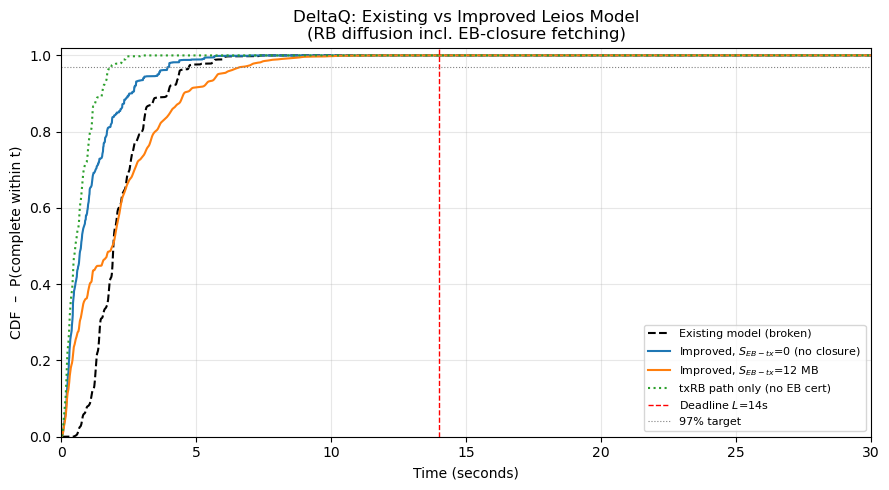

In [9]:
_N_SWEEP = 30
COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, _N_SWEEP))


def plot_cdf_comparison(ref_cdf, results):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(TIMES, ref_cdf, "k--", lw=1.5, label="Existing model (broken)")
    r0 = next(r for r in results if r["s_eb_tx_kb"] == 0)
    ax.plot(TIMES, r0["cdf_comb"], color="tab:blue", lw=1.5,
            label="Improved, $S_{EB-tx}$=0 (no closure)")
    r12 = next(r for r in results if r["s_eb_tx_kb"] == 12288)
    ax.plot(TIMES, r12["cdf_comb"], color="tab:orange", lw=1.5,
            label="Improved, $S_{EB-tx}$=12 MB")
    ax.plot(TIMES, r0["cdf_tx"], color="tab:green", lw=1.5, ls=":",
            label="txRB path only (no EB cert)")
    ax.axvline(L_DEADLINE, color="red", ls="--", lw=1,
               label=f"Deadline $L$={int(L_DEADLINE)}s")
    ax.axhline(0.97, color="gray", ls=":", lw=0.8, label="97% target")
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF  –  P(complete within t)")
    ax.set_title("DeltaQ: Existing vs Improved Leios Model\n"
                 "(RB diffusion incl. EB-closure fetching)")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 30); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_cdf_comparison(ref_cdf, results_mathis)


**EB-closure CDF sweep** — one curve per $S_{EB\text{-}tx}$
value, showing how the certRB path (left) and the combined p_cert-weighted
outcome (right) shift with closure size.


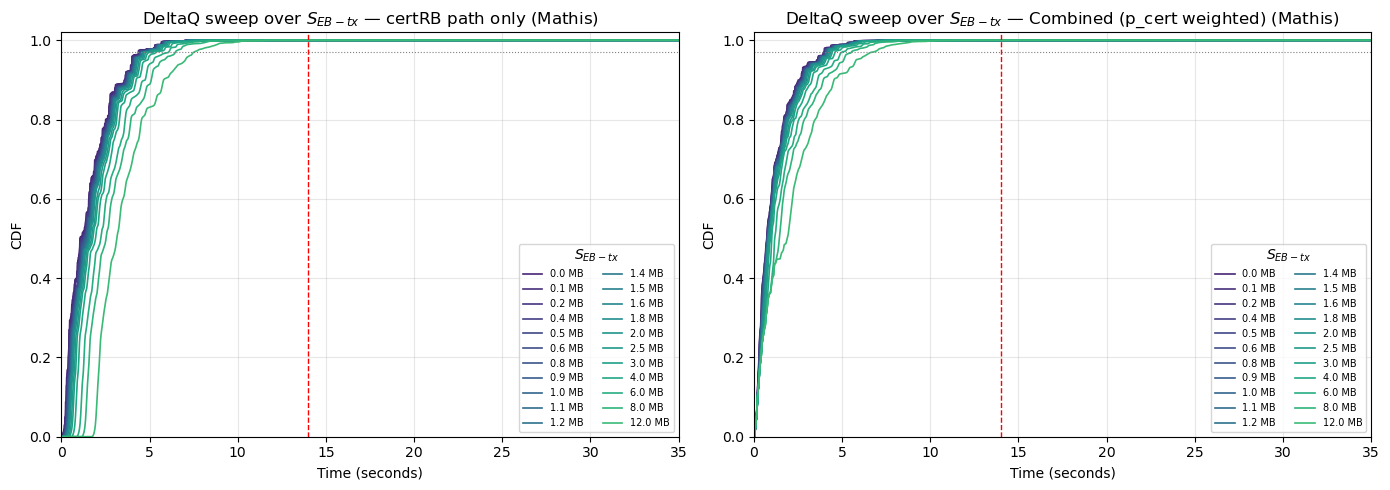

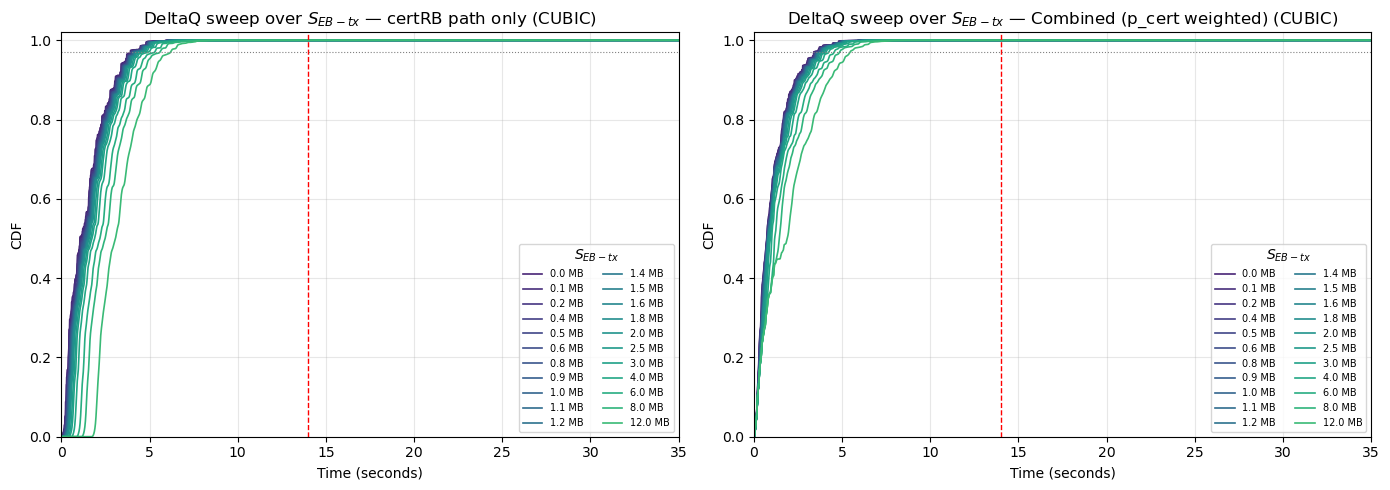

In [10]:
def plot_eb_closure_sweep(results, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1, ax2 = axes
    for i, r in enumerate(results):
        label = f"{r['s_eb_tx_kb']/1024:.1f} MB"
        ax1.plot(TIMES, r["cdf_cert"], color=COLORS[i], lw=1.2, label=label)
        ax2.plot(TIMES, r["cdf_comb"], color=COLORS[i], lw=1.2, label=label)
    for ax, title in [(ax1, "certRB path only"), (ax2, "Combined (p_cert weighted)")]:
        ax.axvline(L_DEADLINE, color="red", ls="--", lw=1)
        ax.axhline(0.97, color="gray", ls=":", lw=0.8)
        ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
        ax.set_title(f"DeltaQ sweep over $S_{{EB-tx}}$ — {title}{title_suffix}")
        ax.set_xlim(0, 35); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
        ax.legend(loc="lower right", fontsize=7, title="$S_{EB-tx}$", ncol=2)
    fig.tight_layout(); plt.show()


plot_eb_closure_sweep(results_mathis, " (Mathis)")
plot_eb_closure_sweep(results_cubic, " (CUBIC)")


**Feasibility** — three probability curves vs $S_{EB-tx}$:
$P_\text{cert}$ (liveness), $P(\text{certRB} \leq 14s)$ (safety), and their
product.  Both panels stay essentially flat at the Praos cap across the full
0–12 MB range under either model.


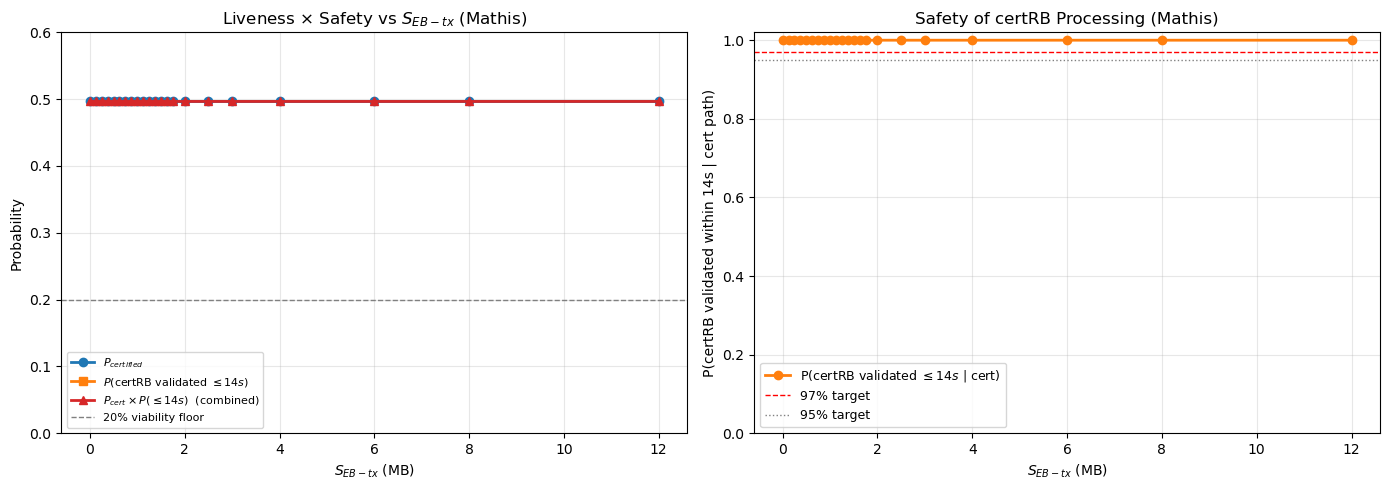

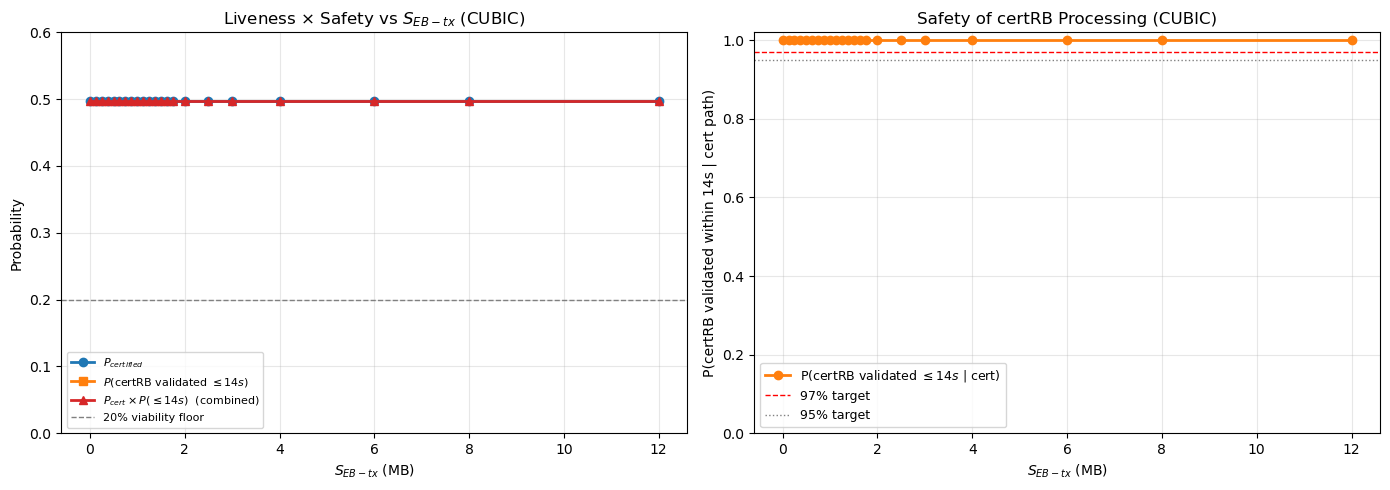

In [11]:
def plot_feasibility(results, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    mbs = [r["s_eb_tx_kb"] / 1024 for r in results]
    sw_cert = [r["sw14_cert"] for r in results]
    p_c = [r["p_cert"] for r in results]
    cas = [r["p_cert_and_safe"] for r in results]
    ax1.plot(mbs, p_c, "o-", color="tab:blue", lw=2, label="$P_{certified}$")
    ax1.plot(mbs, sw_cert, "s-", color="tab:orange", lw=2,
             label="$P$(certRB validated $\\leq 14s$)")
    ax1.plot(mbs, cas, "^-", color="tab:red", lw=2,
             label="$P_{cert} \\times P(\\leq 14s)$  (combined)")
    ax1.axhline(0.20, color="gray", ls="--", lw=1, label="20% viability floor")
    ax1.set_xlabel("$S_{EB-tx}$ (MB)"); ax1.set_ylabel("Probability")
    ax1.set_title(f"Liveness × Safety vs $S_{{EB-tx}}${title_suffix}")
    ax1.legend(fontsize=8); ax1.set_ylim(0, 0.60); ax1.grid(True, alpha=0.3)

    ax2.plot(mbs, sw_cert, "o-", color="tab:orange", lw=2,
             label="P(certRB validated $\\leq 14s$ | cert)")
    ax2.axhline(0.97, color="red", ls="--", lw=1, label="97% target")
    ax2.axhline(0.95, color="gray", ls=":", lw=1, label="95% target")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)")
    ax2.set_ylabel("P(certRB validated within 14s | cert path)")
    ax2.set_title(f"Safety of certRB Processing{title_suffix}")
    ax2.legend(fontsize=9); ax2.set_ylim(0, 1.02); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_feasibility(results_mathis, " (Mathis)")
plot_feasibility(results_cubic, " (CUBIC)")


**Certification components** — the three sub-probabilities
$P_\text{validating}$, $P_\text{quorum}$, $P_\text{cert}$ vs $S_{EB-tx}$ (left),
and the quantile envelope of combined RB completion time (right).


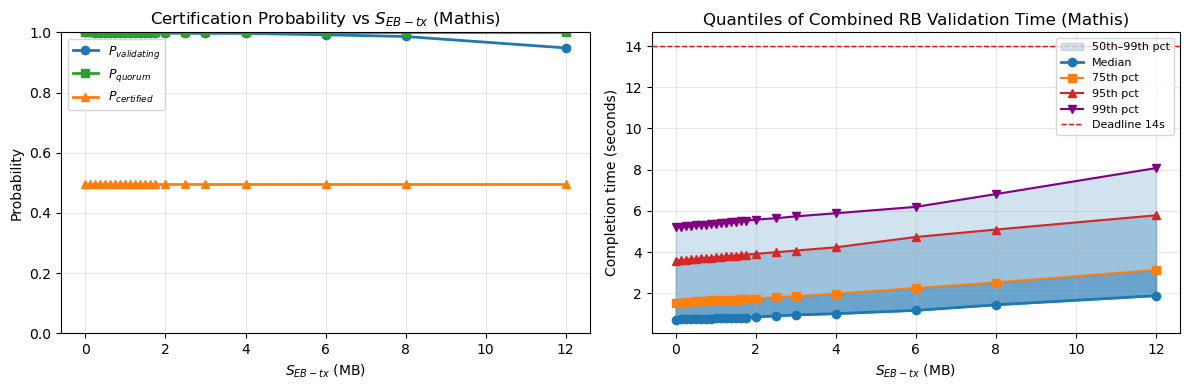

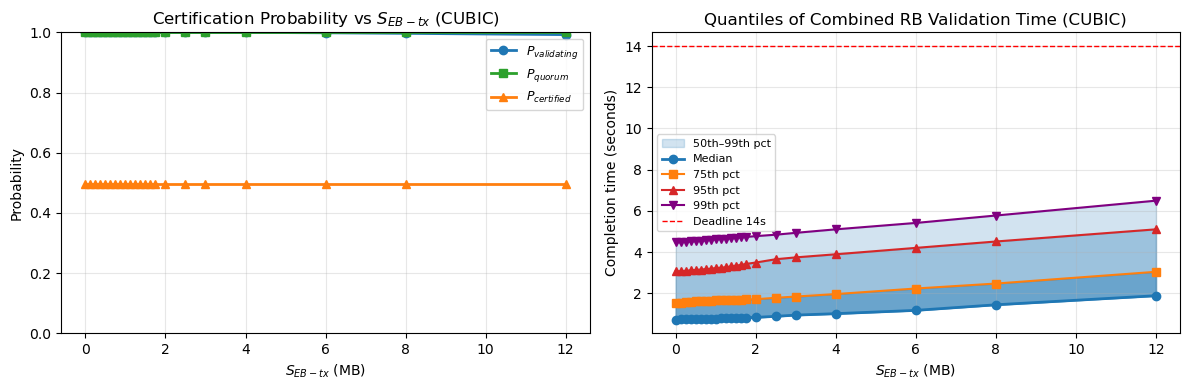

In [12]:
def plot_certification(results, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    mbs = [r["s_eb_tx_kb"] / 1024 for r in results]
    p_v = [r["p_validating"] for r in results]
    p_q = [r["p_quorum"] for r in results]
    p_c = [r["p_cert"] for r in results]
    ax1.plot(mbs, p_v, "o-", color="tab:blue", lw=2, label="$P_{validating}$")
    ax1.plot(mbs, p_q, "s-", color="tab:green", lw=2, label="$P_{quorum}$")
    ax1.plot(mbs, p_c, "^-", color="tab:orange", lw=2, label="$P_{certified}$")
    ax1.set_xlabel("$S_{EB-tx}$ (MB)"); ax1.set_ylabel("Probability")
    ax1.set_title(f"Certification Probability vs $S_{{EB-tx}}${title_suffix}")
    ax1.legend(fontsize=9); ax1.set_ylim(0, 1.0); ax1.grid(True, alpha=0.3)

    q50 = [r["q50"] for r in results]
    q75 = [r["q75"] for r in results]
    q95 = [r["q95"] for r in results]
    q99 = [r["q99"] for r in results]
    ax2.fill_between(mbs, q50, q99, alpha=0.2, color="tab:blue", label="50th–99th pct")
    ax2.fill_between(mbs, q50, q95, alpha=0.3, color="tab:blue")
    ax2.fill_between(mbs, q50, q75, alpha=0.4, color="tab:blue")
    ax2.plot(mbs, q50, "o-", color="tab:blue", lw=2, label="Median")
    ax2.plot(mbs, q75, "s-", color="tab:orange", lw=1.5, label="75th pct")
    ax2.plot(mbs, q95, "^-", color="tab:red", lw=1.5, label="95th pct")
    ax2.plot(mbs, q99, "v-", color="purple", lw=1.5, label="99th pct")
    ax2.axhline(L_DEADLINE, color="red", ls="--", lw=1, label=f"Deadline {int(L_DEADLINE)}s")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)"); ax2.set_ylabel("Completion time (seconds)")
    ax2.set_title(f"Quantiles of Combined RB Validation Time{title_suffix}")
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_certification(results_mathis, " (Mathis)")
plot_certification(results_cubic, " (CUBIC)")


### 5.2 Network Diffusion of the EB Closure

With CPU no longer the binding constraint, network diffusion is the primary
bottleneck.  Two scenarios:

- **1-hop approximation** (voter path in §5.1): each cache-miss node fetches
  only the missing fraction ($\pi_1 \cdot S_{EB-tx}$) from its upstream peer.
- **Full blended diffusion** (worst case — transactions not pre-diffused):
  the entire $S_{EB-tx}$ traverses the blended multi-hop network.


In [13]:
def run_network_diffusion():
    """
    Compute network-only diffusion time for the EB closure under two models:
      (a) 1-hop approximation: node fetches only the missing fraction (π₁·S_EB_tx)
          from its upstream peer (one hop).  Justified if the raw transactions
          referenced by the EB have already diffused via tx-submission before
          the EB is produced.  (Linear Leios has no Input Blocks; transactions
          diffuse solely via tx-submission.)
      (b) Full blended diffusion: the entire S_EB_tx must traverse the blended
          multi-hop network (worst case: transactions not pre-diffused).

    CPU reapplication is NOT included – this isolates the network constraint.
    """
    sweep_kb = [512, 1024, 1536, 2048, 4096, 8192, 12288]

    rows = []
    for s_kb in sweep_kb:
        miss_kb = TX_CACHE_MISS_RATE * s_kb  # π₁ · S_EB_tx

        # (a) 1-hop for missing fraction
        net_1hop = cdf_sequential(cdf_fetch_eb_body(), cdf_hop(miss_kb))
        # (b) blended multi-hop for missing fraction
        net_miss_blended = cdf_sequential(
            cdf_fetch_eb_body(), cdf_blended_delay(miss_kb)
        )
        # (c) full closure blended (no 1-hop shortcut)
        net_full_blended = cdf_blended_delay(s_kb)

        rows.append(
            dict(
                s_kb=s_kb,
                net_1hop=net_1hop,
                net_miss_blend=net_miss_blended,
                net_full_blend=net_full_blended,
                sw7_1hop=success_within(net_1hop, 7.0),
                sw7_miss_blend=success_within(net_miss_blended, 7.0),
                sw14_full=success_within(net_full_blended, 14.0),
                sw7_full=success_within(net_full_blended, 7.0),
            )
        )
    return rows


/tmp/nix-shell.TEShlY/ipykernel_218822/1540215392.py:25: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "v-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(mbs, [r["sw7_full"] for r in rows], "v-", color="purple",


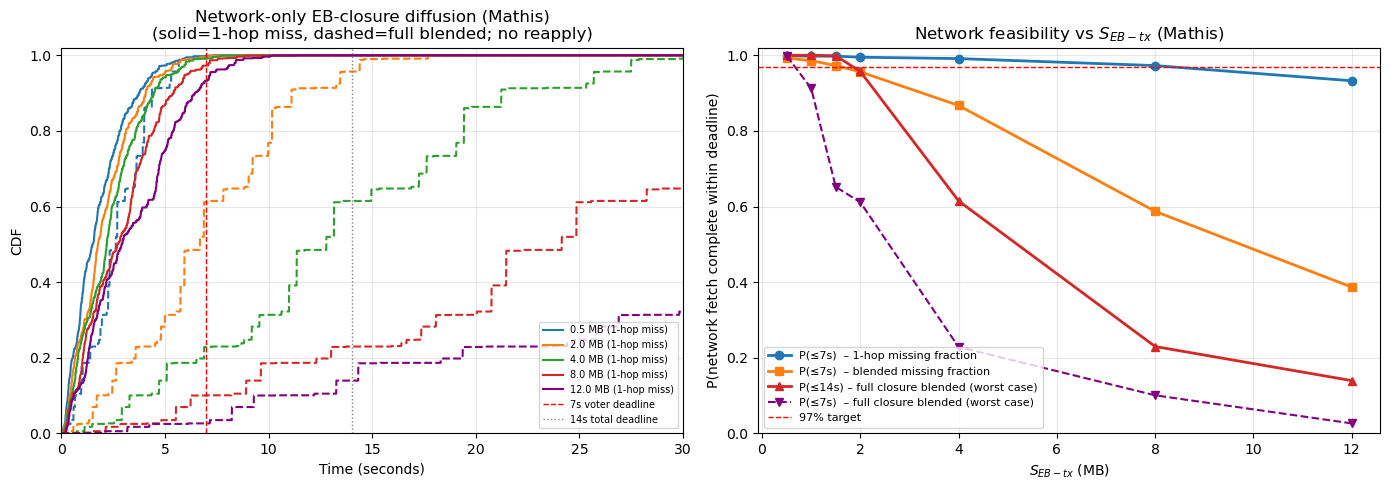

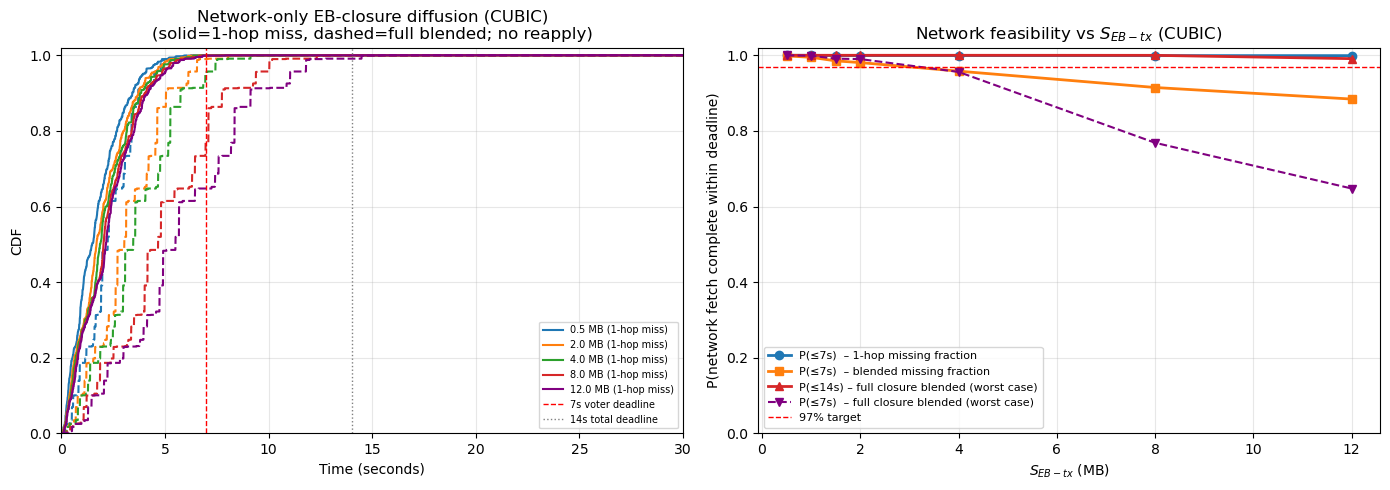

In [14]:
def plot_network_diffusion(rows, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    highlight = [512, 2048, 4096, 8192, 12288]
    colors_h = ["tab:blue", "tab:orange", "tab:green", "tab:red", "purple"]
    for row, col in zip([r for r in rows if r["s_kb"] in highlight], colors_h):
        lbl = f"{row['s_kb']/1024:.1f} MB"
        ax1.plot(TIMES, row["net_1hop"], color=col, lw=1.5, ls="-",
                 label=f"{lbl} (1-hop miss)")
        ax1.plot(TIMES, row["net_full_blend"], color=col, lw=1.5, ls="--")
    ax1.axvline(7.0, color="red", ls="--", lw=1, label="7s voter deadline")
    ax1.axvline(14.0, color="gray", ls=":", lw=1, label="14s total deadline")
    ax1.set_xlabel("Time (seconds)"); ax1.set_ylabel("CDF")
    ax1.set_title(f"Network-only EB-closure diffusion{title_suffix}\n"
                 "(solid=1-hop miss, dashed=full blended; no reapply)")
    ax1.legend(fontsize=7, loc="lower right")
    ax1.set_xlim(0, 30); ax1.set_ylim(0, 1.02); ax1.grid(True, alpha=0.3)

    mbs = [r["s_kb"] / 1024 for r in rows]
    ax2.plot(mbs, [r["sw7_1hop"] for r in rows], "o-", color="tab:blue", lw=2,
             label="P(≤7s)  – 1-hop missing fraction")
    ax2.plot(mbs, [r["sw7_miss_blend"] for r in rows], "s-", color="tab:orange",
             lw=2, label="P(≤7s)  – blended missing fraction")
    ax2.plot(mbs, [r["sw14_full"] for r in rows], "^-", color="tab:red",
             lw=2, label="P(≤14s) – full closure blended (worst case)")
    ax2.plot(mbs, [r["sw7_full"] for r in rows], "v-", color="purple",
             lw=1.5, ls="--", label="P(≤7s)  – full closure blended (worst case)")
    ax2.axhline(0.97, color="red", ls="--", lw=1, label="97% target")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)")
    ax2.set_ylabel("P(network fetch complete within deadline)")
    ax2.set_title(f"Network feasibility vs $S_{{EB-tx}}${title_suffix}")
    ax2.legend(fontsize=8, loc="lower left"); ax2.set_ylim(0, 1.02)
    ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


set_network_model("mathis"); net_mathis = run_network_diffusion()
plot_network_diffusion(net_mathis, " (Mathis)")

set_network_model("cubic"); net_cubic = run_network_diffusion()
plot_network_diffusion(net_cubic, " (CUBIC)")


### 5.3 Sensitivity: 1-hop vs Multi-hop EB Closure Fetch

For every CIP-target size up to 12 MB, the 1-hop and blended-missing
multi-hop models both give $P_\text{cert}$ at the Praos cap $\approx 0.497$
under either throughput model — the missing-closure fetch
($\pi_1 \cdot S$, up to 2 MB at 12 MB for $\pi_1 = 1/6$) is small enough to
complete in time even over multi-hop paths.

The cell below reproduces the per-model CDF comparison at $S_{EB-tx}$ = 12 MB.


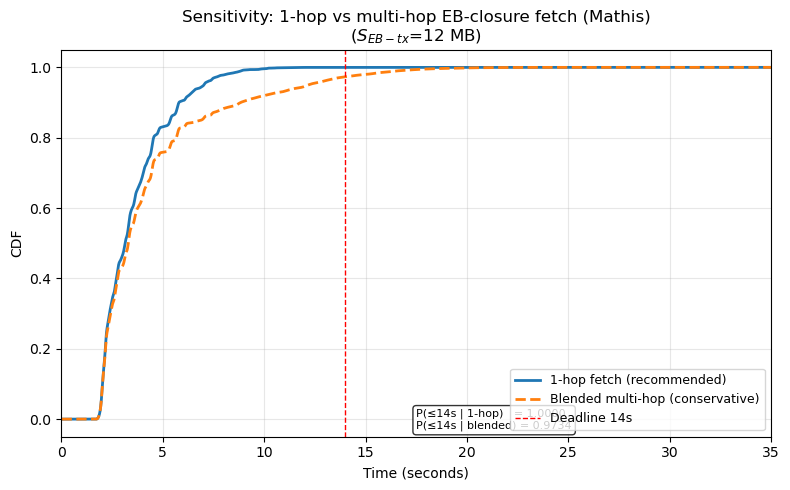

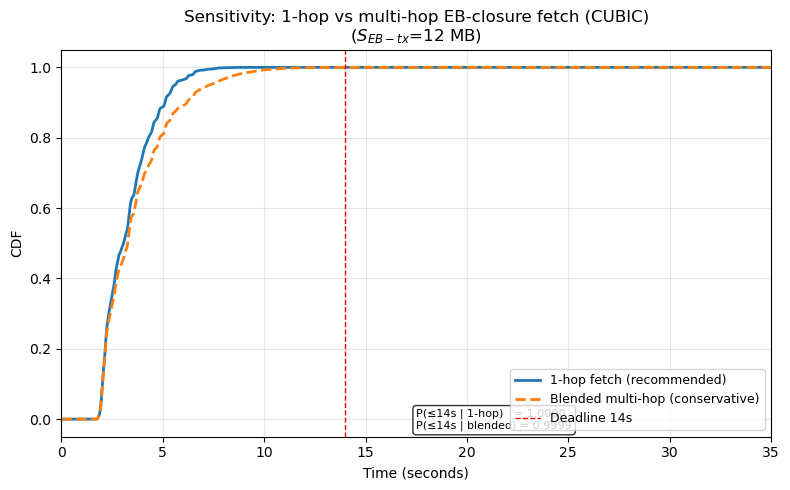

Mathis: {'1hop_sw14': 0.9999984110653874, 'blended_sw14': 0.9734374657658752}
CUBIC : {'1hop_sw14': 0.999999999999999, 'blended_sw14': 0.999944939409249}


In [15]:
def sensitivity_1hop_vs_blended(title_suffix=""):
    s_kb = 12288  # === edit: switch to a smaller closure to see the gap shrink ===
    cert_1hop = cdf_process_cert_rb(s_kb)

    eb_body = cdf_fetch_eb_body()
    cert_rb = cdf_fetch_cert_rb_body()
    missing_kb = TX_CACHE_MISS_RATE * s_kb
    miss_blended = cdf_choice(TX_CACHE_HIT_RATE, cdf_wait(0.001),
                              cdf_blended_delay(missing_kb))
    eb_blended = cdf_sequential(eb_body, miss_blended)
    parallel_b = cdf_last_to_finish(cert_rb, eb_blended)
    cert_blended = cdf_sequential(parallel_b, reapply_txs_cdf(s_kb))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(TIMES, cert_1hop, lw=2, label="1-hop fetch (recommended)")
    ax.plot(TIMES, cert_blended, lw=2, ls="--",
            label="Blended multi-hop (conservative)")
    ax.axvline(L_DEADLINE, color="red", ls="--", lw=1,
               label=f"Deadline {int(L_DEADLINE)}s")
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(f"Sensitivity: 1-hop vs multi-hop EB-closure fetch{title_suffix}\n"
                 f"($S_{{EB-tx}}$={s_kb/1024:.0f} MB)")
    ax.legend(fontsize=9); ax.set_xlim(0, 35); ax.grid(True, alpha=0.3)
    ax.text(0.5, 0.02,
            f"P(≤14s | 1-hop)   = {success_within(cert_1hop,14):.4f}\n"
            f"P(≤14s | blended) = {success_within(cert_blended,14):.4f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    fig.tight_layout(); plt.show()
    return {"1hop_sw14": success_within(cert_1hop, 14.0),
            "blended_sw14": success_within(cert_blended, 14.0)}


set_network_model("mathis"); sens_mathis = sensitivity_1hop_vs_blended(" (Mathis)")
set_network_model("cubic"); sens_cubic = sensitivity_1hop_vs_blended(" (CUBIC)")
print("Mathis:", sens_mathis); print("CUBIC :", sens_cubic)


### 5.4 Network Model Sensitivity (Mathis vs CUBIC vs loss rate)

Quantify how each throughput model responds to packet loss $p$, and where the
2 MB long-haul fetch crosses the 7 s voter deadline.

| Throughput model | $p$ at which 2 MB long-haul = 7 s |
|------------------|-----------------------------------|
| Mathis           | $\approx 2.8 \times 10^{-4}$      |
| CUBIC            | $\approx 4.6 \times 10^{-3}$      |

The analysis default $p = 10^{-4}$ lies well below both crossings.


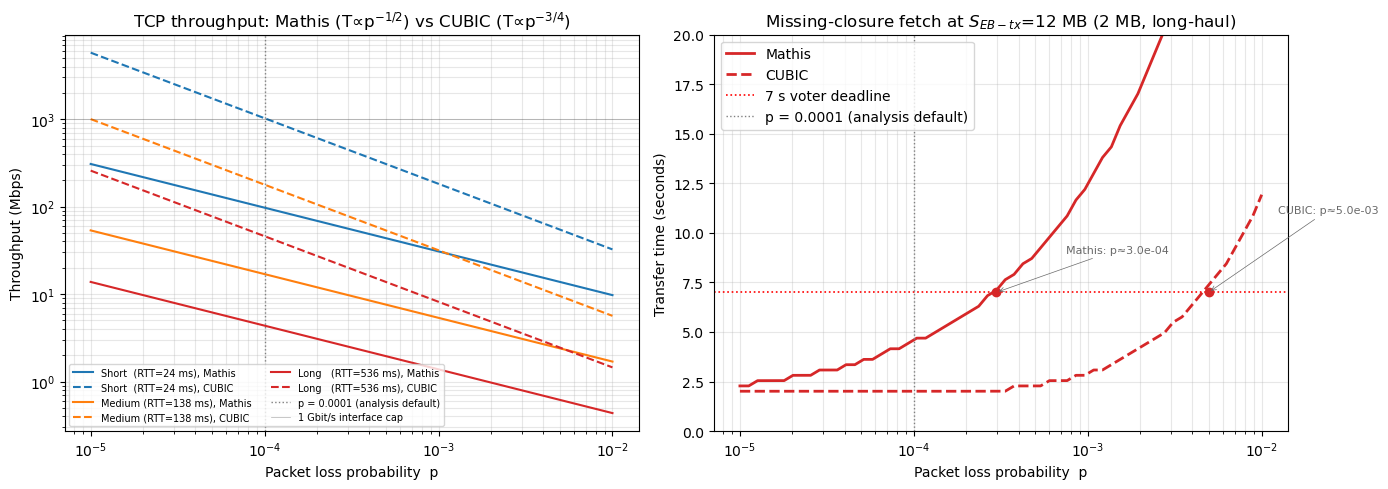

In [16]:
def plot_network_model_comparison():
    p_grid = np.logspace(-5, -2, 60)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    distances = [
        ("Short  (RTT=24 ms)",  _OWD_SHORT_S, "tab:blue"),
        ("Medium (RTT=138 ms)", _OWD_MED_S,   "tab:orange"),
        ("Long   (RTT=536 ms)", _OWD_LONG_S,  "tab:red"),
    ]
    for label, owd, color in distances:
        rtt = 2.0 * owd
        T_m = np.array([_steady_state_window("mathis", p) / rtt * 8 / 1e6 for p in p_grid])
        T_c = np.array([_steady_state_window("cubic", p)  / rtt * 8 / 1e6 for p in p_grid])
        ax1.loglog(p_grid, T_m, "-",  color=color, lw=1.5, label=f"{label}, Mathis")
        ax1.loglog(p_grid, T_c, "--", color=color, lw=1.5, label=f"{label}, CUBIC")
    ax1.axvline(_TCP_LOSS, color="gray", ls=":", lw=1,
                label=f"p = {_TCP_LOSS:g} (analysis default)")
    ax1.axhline(1e3, color="black", ls="-", lw=0.5, alpha=0.3,
                label="1 Gbit/s interface cap")
    ax1.set_xlabel("Packet loss probability  p"); ax1.set_ylabel("Throughput (Mbps)")
    ax1.set_title("TCP throughput: Mathis (T∝p$^{-1/2}$) vs CUBIC (T∝p$^{-3/4}$)")
    ax1.grid(alpha=0.3, which="both"); ax1.legend(fontsize=7, loc="lower left", ncol=2)

    t_m = np.array([_tcp_transfer_time(2048, _OWD_LONG_S, "mathis", p) for p in p_grid])
    t_c = np.array([_tcp_transfer_time(2048, _OWD_LONG_S, "cubic", p)  for p in p_grid])
    ax2.semilogx(p_grid, t_m, "-",  color="tab:red", lw=2, label="Mathis")
    ax2.semilogx(p_grid, t_c, "--", color="tab:red", lw=2, label="CUBIC")
    ax2.axhline(7.0, color="red", ls=":", lw=1.2, label="7 s voter deadline")
    ax2.axvline(_TCP_LOSS, color="gray", ls=":", lw=1,
                label=f"p = {_TCP_LOSS:g} (analysis default)")
    for arr, name in [(t_m, "Mathis"), (t_c, "CUBIC")]:
        idx = int(np.searchsorted(arr, 7.0))
        if 0 < idx < len(p_grid):
            ax2.plot(p_grid[idx], 7.0, "o", color="tab:red", ms=6)
            ax2.annotate(f"{name}: p≈{p_grid[idx]:.1e}",
                         xy=(p_grid[idx], 7.0),
                         xytext=(p_grid[idx]*2.5, 9 if name=="Mathis" else 11),
                         fontsize=8, color="dimgray",
                         arrowprops=dict(arrowstyle="->", color="dimgray", lw=0.5))
    ax2.set_ylim(0, 20)
    ax2.set_xlabel("Packet loss probability  p"); ax2.set_ylabel("Transfer time (seconds)")
    ax2.set_title("Missing-closure fetch at $S_{EB-tx}$=12 MB (2 MB, long-haul)")
    ax2.grid(alpha=0.3, which="both"); ax2.legend(loc="upper left")
    fig.tight_layout(); plt.show()


plot_network_model_comparison()


### 5.5 TxCache Miss Rate Sensitivity (π₁ sweep)

The default cache miss rate $\pi_1 = 1/6 \approx 0.17$ is inherited from the
prior Haskell ΔQ model.  An empirical extraction from
`post-cip/mempool-measurements/` (see `pi1_derivation.md`) gives:

| Source | $\pi_1$ |
|--------|---------|
| Prior model (hand-chosen Markov) | **0.167** |
| Empirical mean (cross-region BAU) | **0.06** |
| Empirical worst-case pair | **0.085** |
| Empirical range | [0.02, 0.09] |

The prior value is ~3× the empirical mean.  The sweep below confirms the
12 MB target is feasible under every $\pi_1 \leq 1/6$ in both models, with
sensitivity emerging only at $\pi_1 \geq 0.50$ under Mathis.


In [17]:
PI1_SWEEP_VALUES = (0.05, 0.10, 1.0 / 6.0, 0.30, 0.50)


def run_pi1_sensitivity(pi1_values=PI1_SWEEP_VALUES):
    """
    For each (network model × π₁) combination, run the full S_EB_tx sweep
    and collect P_validating, P_cert and the safety probability.

    Returns: { model_label: { pi1: [results_dict, ...], ... }, ... }
    """
    # Cache the active state so we can restore it on exit.
    saved_model = NETWORK_MODEL
    saved_pi1 = TX_CACHE_MISS_RATE

    out = {}
    for model in ("mathis", "cubic"):
        set_network_model(model)
        out[model] = {}
        for pi1 in pi1_values:
            set_cache_miss_rate(pi1)
            print(
                f"  [π₁ sensitivity] model={model:6s}  π₁={pi1:.4f}  ...",
                end="",
                flush=True,
            )
            out[model][pi1] = run_sweep()
            r12 = next(
                (r for r in out[model][pi1] if abs(r["s_eb_tx_kb"] - 12288) < 1), None
            )
            if r12:
                print(f"  P_cert@12MB = {r12['p_cert']:.4f}")
            else:
                print()

    set_network_model(saved_model)
    set_cache_miss_rate(saved_pi1)
    return out

def print_pi1_sensitivity_summary(sens):
    """Console table: P_cert @ S_EB_tx ∈ {1, 4, 8, 12 MB} for each model × π₁."""
    print("\n" + "=" * 78)
    print("π₁ SENSITIVITY — P_cert at selected S_EB_tx (per model)")
    print("=" * 78)
    sizes_kb = [1024, 4096, 8192, 12288]
    for model in ("mathis", "cubic"):
        print(f"\n[{model.upper()}]")
        header = f"  {'π₁':>6}  " + "  ".join(f"{s/1024:>4.0f}MB" for s in sizes_kb)
        print(header)
        print("  " + "-" * (len(header) - 2))
        for pi1, rs in sorted(sens[model].items()):
            cells = []
            for s_kb in sizes_kb:
                r = next((x for x in rs if abs(x["s_eb_tx_kb"] - s_kb) < 1), None)
                cells.append(f"{r['p_cert']:.3f}" if r else "  —")
            tag = "1/6" if abs(pi1 - 1 / 6) < 1e-4 else f"{pi1:.3f}"
            print(f"  {tag:>6}  " + "  ".join(f"{c:>6s}" for c in cells))


  [π₁ sensitivity] model=mathis  π₁=0.0500  ...

   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   0.9997    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.56    5.23
  0.125 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.74    1.55    3.57    5.24
  0.250 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.59    5.25
  0.375 MB   0.9992    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.60    5.26


  0.500 MB   0.9980    1.0000   0.4966     1.0000       0.4966    0.74    1.57    3.61    5.27
  0.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.58    3.63    5.28
  0.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.59    3.64    5.30
  0.875 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.60    3.65    5.31
  1.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.61    3.67    5.32


  1.125 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.62    3.68    5.33
  1.250 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.63    3.69    5.34
  1.375 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.71    5.36
  1.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.72    5.37
  1.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.65    3.73    5.38
  1.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.65    3.74    5.39


  2.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.79    1.65    3.77    5.41
  2.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.80    1.66    3.82    5.46
  3.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.83    1.69    3.87    5.51
  4.000 MB   0.9976    1.0000   0.4966     1.0000       0.4966    0.86    1.74    3.97    5.61
  6.000 MB   0.9975    1.0000   0.4966     1.0000       0.4966    0.99    1.89    4.16    5.81
  8.000 MB   0.9974    1.0000   0.4966     1.0000       0.4966    1.13    2.07    4.35    6.00


...

  2.500 MB   0.9963    1.0000   0.4966     1.0000       0.4966    1.15    2.36    4.39    5.65


  3.000 MB   0.9955    1.0000   0.4966     1.0000       0.4966    1.26    2.49    4.55    5.84


  4.000 MB   0.9927    1.0000   0.4966     1.0000       0.4966    1.50    2.78    4.87    6.25


  6.000 MB   0.9810    1.0000   0.4966     1.0000       0.4966    1.94    3.37    5.52    6.97
  8.000 MB   0.9559    1.0000   0.4966     1.0000       0.4966    2.39    3.97    6.21    7.70


 12.000 MB   0.8443    1.0000   0.4966     1.0000       0.4966    2.40    5.17    7.57    9.11
  P_cert@12MB = 0.4966


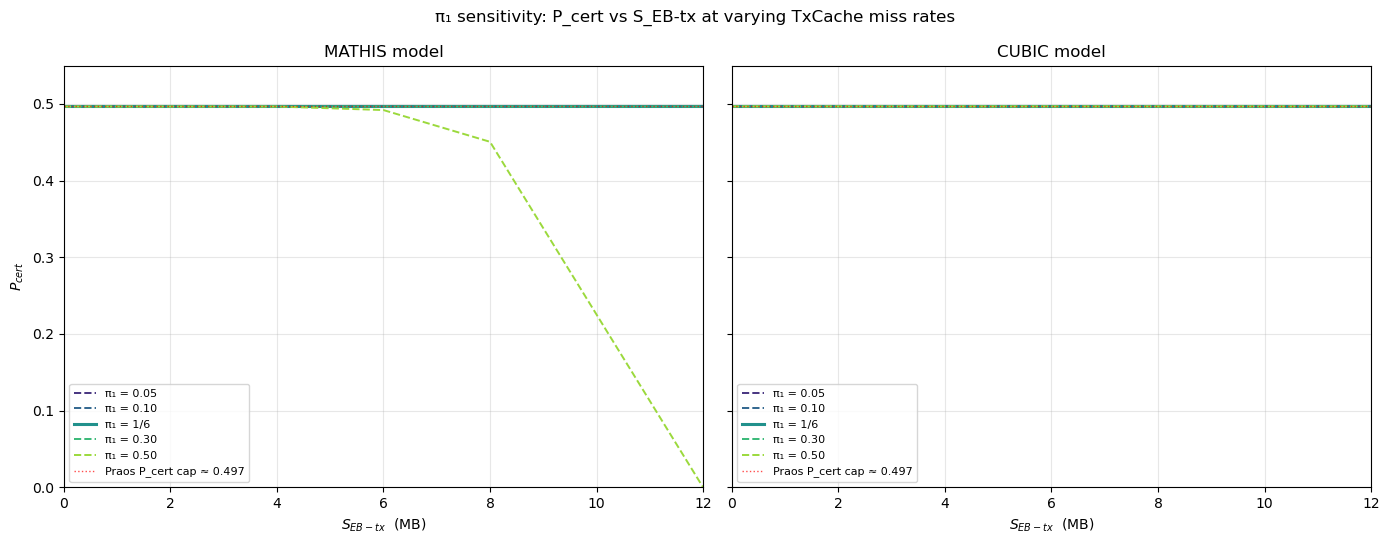


π₁ SENSITIVITY — P_cert at selected S_EB_tx (per model)

[MATHIS]
      π₁     1MB     4MB     8MB    12MB
  --------------------------------------
   0.050   0.497   0.497   0.497   0.497
   0.100   0.497   0.497   0.497   0.497
     1/6   0.497   0.497   0.497   0.497
   0.300   0.497   0.497   0.497   0.497
   0.500   0.497   0.497   0.451   0.000

[CUBIC]
      π₁     1MB     4MB     8MB    12MB
  --------------------------------------
   0.050   0.497   0.497   0.497   0.497
   0.100   0.497   0.497   0.497   0.497
     1/6   0.497   0.497   0.497   0.497
   0.300   0.497   0.497   0.497   0.497
   0.500   0.497   0.497   0.497   0.497


In [18]:
def plot_pi1_sensitivity(sens):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    pi1_values = sorted(next(iter(sens.values())).keys())
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(pi1_values)))
    for ax, model in zip(axes, ("mathis", "cubic")):
        for pi1, color in zip(pi1_values, cmap):
            rs = sens[model][pi1]
            mbs = [r["s_eb_tx_kb"]/1024 for r in rs]
            pcs = [r["p_cert"] for r in rs]
            tag = "1/6" if abs(pi1 - 1/6) < 1e-4 else f"{pi1:.2f}"
            lw = 2.2 if abs(pi1 - 1/6) < 1e-4 else 1.4
            ls = "-"  if abs(pi1 - 1/6) < 1e-4 else "--"
            ax.plot(mbs, pcs, ls, color=color, lw=lw, label=f"π₁ = {tag}")
        ax.axhline(0.497, color="red", ls=":", lw=1, alpha=0.7,
                   label="Praos P_cert cap ≈ 0.497")
        ax.set_xlabel("$S_{EB-tx}$  (MB)"); ax.set_title(f"{model.upper()} model")
        ax.set_xlim(0, 12); ax.set_ylim(0, 0.55); ax.grid(alpha=0.3)
        ax.legend(loc="lower left", fontsize=8)
    axes[0].set_ylabel("$P_{cert}$")
    fig.suptitle("π₁ sensitivity: P_cert vs S_EB-tx at varying TxCache miss rates",
                 fontsize=12)
    fig.tight_layout(); plt.show()


pi1_sens = run_pi1_sensitivity()
plot_pi1_sensitivity(pi1_sens)
print_pi1_sensitivity_summary(pi1_sens)


### 5.6 Full Diffusion Conditional on Certification

Security Assumption 1 (Panagiotakos report) requires that a certified EB
reaches **all** honest nodes by the end of $L_\text{diff}$.  Here we compute
the conditional CDF

$$F_{\text{full}\mid C}(t)\;:=\;P\!\left(\max_{j=1\ldots N} T_j \le t \;\bigg|\; C\right)$$

where $T_j$ is the EB-body arrival time at node $j$ and $C$ is the certification
event "$\ge \tau M$ committee voters validated the EB by $t_v = 3L_\text{hdr}+L_\text{vote}=7\,\text{s}$".

**Closed form.** Assuming $T_j$ are i.i.d. samples from $G(t) :=$ `cdf_blended_delay(s_eb_body_kb)`
(per-node EB-body arrival CDF, with hop-count randomness already mixed in
via `_HOP_PROBS`):

$$F_{\text{full}\mid C}(t)\;=\;\dfrac{G(t)^N \cdot \overline{B}\!\left(\lceil\tau M\rceil - 1;\, M,\, G(t_v)/G(t)\right)}{P(C)}\quad(t \ge t_v),$$

with $\overline{B}$ the upper-tail Binomial CDF and $P(C) = \overline{B}(\lceil\tau M\rceil-1;\, M, G(t_v))$.
For $t < t_v$ the expression collapses to $G(t)^N / P(C)$ (all voters must be
"fast," so $K_v = M \ge \tau M$ automatically).

**Derivation sketch.** Voter $i$ falls in one of three buckets given $t \ge t_v$:
fast ($T_i \le t_v$, prob $G(t_v)$), medium ($t_v < T_i \le t$, prob $G(t)-G(t_v)$),
slow ($T_i > t$, prob $1-G(t)$).  Conditional on "no slow voter," each voter is
"fast" with probability $G(t_v)/G(t)$, so the fast-voter count is
$\text{Bin}(M,\, G(t_v)/G(t))$.  Multiplying by $G(t)^{N-M}$ for the
independent non-voter sample completes the joint $G(t)^N \cdot \overline{B}(\cdot)$.

**Caveats.**
- **i.i.d. is pessimistic for "all":** real $T_j$'s are positively correlated
  (shared paths), so the true $F_{\text{full}\mid C}$ is *larger* than the
  formula gives.  A worst-case bound on the slowest path alone is
  `cdf_hops(5, s_eb_body_kb)`.
- **Committee size fixed at $M$:** the Poisson-sortition variability is
  absorbed into $P(C)$; if desired, swap `binom.sf` for the Normal
  approximation already used in `compute_p_certified`.
- **Delivery only, no validation CPU:** $G$ here is the body-diffusion CDF,
  not the voter validation CDF.


In [19]:
def cdf_full_diffusion_given_cert(
    s_eb_body_kb: float,
    n_nodes: int = 2500,
    committee_size: int = 600,
    tau: float = 0.75,
    t_vote: float = 7.0,
) -> np.ndarray:
    """
    Conditional CDF F_{full|C}(t) = P(all N nodes have the EB by t | EB certified).

    Closed form (see §5.6 markdown):
        For t >= t_vote:
            F_{full|C}(t) = G(t)^N * binom.sf(ceil(tau*M)-1, M, G(t_v)/G(t)) / P(C)
        For t < t_vote:
            F_{full|C}(t) = G(t)^N / P(C)
    where G = cdf_blended_delay(s_eb_body_kb).

    Returns the conditional CDF as an array on the global TIMES grid.
    """
    G = cdf_blended_delay(s_eb_body_kb)
    g_tv = success_within(G, t_vote)

    M = committee_size
    N = n_nodes
    k_thr = int(np.ceil(tau * M))

    # P(C): the marginal certification probability for a fresh, fixed-size committee.
    pC = float(stats.binom.sf(k_thr - 1, M, g_tv))
    if pC <= 0.0:
        return np.zeros_like(G)

    # G(t)^N in log space to avoid underflow for large N.
    with np.errstate(divide="ignore"):
        log_G = np.where(G > 0, np.log(np.clip(G, 1e-300, 1.0)), -np.inf)
    G_pow_N = np.exp(N * log_G)

    # Voter factor: P(Bin(M, G(t_v)/G(t)) >= k_thr) for t >= t_v; else 1.0.
    voter_factor = np.ones_like(G)
    ge_tv = TIMES >= t_vote
    safe_G = np.where(G > 0, G, 1.0)
    p_fast_given_arrived = np.clip(g_tv / safe_G, 0.0, 1.0)
    voter_factor[ge_tv] = stats.binom.sf(k_thr - 1, M, p_fast_given_arrived[ge_tv])

    out = G_pow_N * voter_factor / pC
    return np.clip(out, 0.0, 1.0)


def cdf_full_diffusion_unconditional(
    s_eb_body_kb: float, n_nodes: int = 2500
) -> np.ndarray:
    """
    Unconditional CDF for max_j T_j under the same i.i.d. model: G(t)^N.
    Useful as a baseline curve in the §5.6 plot.
    """
    G = cdf_blended_delay(s_eb_body_kb)
    with np.errstate(divide="ignore"):
        log_G = np.where(G > 0, np.log(np.clip(G, 1e-300, 1.0)), -np.inf)
    return np.exp(n_nodes * log_G)


  s_body  G(t_v)   G(t_f)   P(C)     F_{full|C}(t_f)  G(t_f)^N    F_5(t_f)
  ------------------------------------------------------------------------------
    64kB  1.0000   1.0000   1.0000   1.0000            1.000e+00  1.0000
   256kB  1.0000   1.0000   1.0000   1.0000            1.000e+00  1.0000
   512kB  0.9987   1.0000   1.0000   1.0000            1.000e+00  1.0000


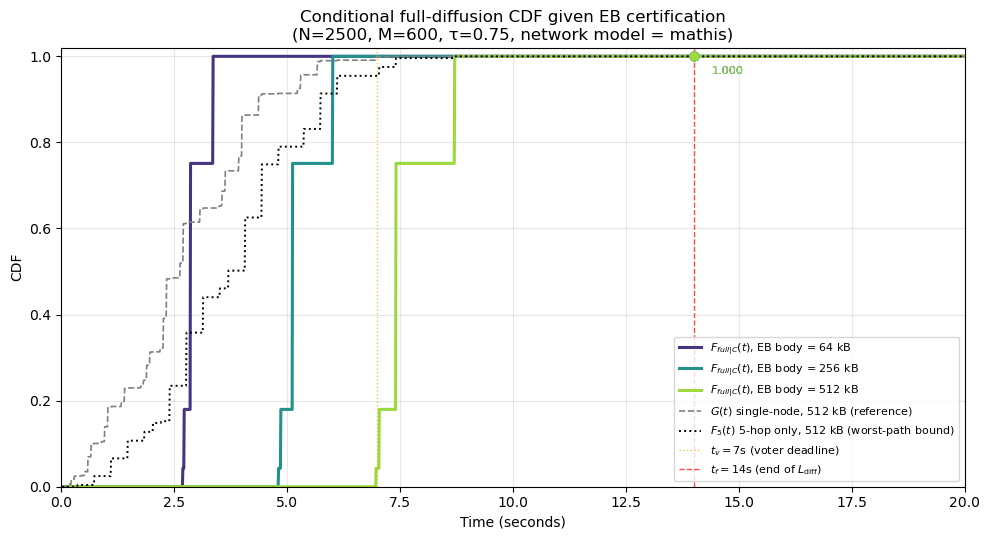

In [20]:
def plot_full_diffusion_given_cert(
    sizes_kb=(64, 256, 512),
    n_nodes=2500,
    committee_size=600,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
):
    """
    Plot F_{full|C}(t) for several EB body sizes alongside:
      - the single-node CDF G(t) = cdf_blended_delay (lower-bound reference)
      - the 5-hop worst-path CDF F_5(t)            (correlated-case bound)
    Annotates F_{full|C}(t_diff_end) at the L_diff deadline.
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(sizes_kb)))

    for s_kb, color in zip(sizes_kb, cmap):
        cdf_cond = cdf_full_diffusion_given_cert(
            s_kb, n_nodes=n_nodes, committee_size=committee_size,
            tau=tau, t_vote=t_vote,
        )
        ax.plot(TIMES, cdf_cond, lw=2.2, color=color,
                label=f"$F_{{full|C}}(t)$, EB body = {s_kb} kB")

        # Annotate value at the L_diff deadline.
        f_at_deadline = success_within(cdf_cond, t_diff_end)
        ax.scatter([t_diff_end], [f_at_deadline], color=color, zorder=5, s=40)
        ax.annotate(
            f"{f_at_deadline:.3f}",
            xy=(t_diff_end, f_at_deadline),
            xytext=(t_diff_end + 0.4, f_at_deadline - 0.04),
            fontsize=8, color=color,
        )

    # Reference: single-node arrival CDF at the largest size (lower bound on
    # "any single node by t", i.e. an optimistic comparison curve).
    ax.plot(TIMES, cdf_blended_delay(max(sizes_kb)),
            ls="--", lw=1.2, color="gray",
            label=f"$G(t)$ single-node, {max(sizes_kb)} kB (reference)")

    # Reference: 5-hop worst-path CDF (correlated-case upper bound on the slowest node).
    ax.plot(TIMES, cdf_hops(5, max(sizes_kb)),
            ls=":", lw=1.4, color="black",
            label=f"$F_5(t)$ 5-hop only, {max(sizes_kb)} kB (worst-path bound)")

    ax.axvline(t_vote, color="orange", ls=":", lw=1, alpha=0.7,
               label=f"$t_v = {t_vote:g}$s (voter deadline)")
    ax.axvline(t_diff_end, color="red", ls="--", lw=1, alpha=0.7,
               label=f"$t_f = {t_diff_end:g}$s (end of $L_\mathrm{{diff}}$)")

    ax.set_xlim(0, 20); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(
        "Conditional full-diffusion CDF given EB certification\n"
        f"(N={n_nodes}, M={committee_size}, τ={tau}, network model = {NETWORK_MODEL})"
    )
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout(); plt.show()


# Print numeric summary at the L_diff deadline for a sweep of EB body sizes.
def print_full_diffusion_summary(
    sizes_kb=(64, 256, 512),
    n_nodes=2500,
    committee_size=600,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
):
    print(f"  s_body  G(t_v)   G(t_f)   P(C)     F_{{full|C}}(t_f)  G(t_f)^N    F_5(t_f)")
    print(f"  " + "-" * 78)
    for s_kb in sizes_kb:
        G = cdf_blended_delay(s_kb)
        g_tv = success_within(G, t_vote)
        g_tf = success_within(G, t_diff_end)
        pC = float(stats.binom.sf(int(np.ceil(tau * committee_size)) - 1,
                                  committee_size, g_tv))
        cdf_cond = cdf_full_diffusion_given_cert(
            s_kb, n_nodes=n_nodes, committee_size=committee_size,
            tau=tau, t_vote=t_vote,
        )
        f_cond = success_within(cdf_cond, t_diff_end)
        f_uncond = g_tf ** n_nodes
        f_5 = success_within(cdf_hops(5, s_kb), t_diff_end)
        print(f"  {s_kb:>4d}kB  {g_tv:.4f}   {g_tf:.4f}   {pC:.4f}   "
              f"{f_cond:.4f}            {f_uncond:.3e}  {f_5:.4f}")


# Use Mathis as a conservative reference for this plot.
set_network_model("mathis")
print_full_diffusion_summary()
plot_full_diffusion_given_cert()


### Outcome diagram (schematic)

Visual flow of the two mutually exclusive RB validation paths after the bug
fix in §3.1.  This is the schematic referenced in §3 and §4.4.


In [21]:
def plot_outcome_diagram():
    """
    Schematic outcome diagram for the improved Linear Leios model.
    Two paths depending on whether the EB was certified.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 12)
    ax.set_ylim(-0.5, 6.5)
    ax.axis("off")
    ax.set_title(
        "Improved Linear Leios – RB Validation Outcome Diagram\n"
        "(fixing the 'cert XOR txs' RB structure)",
        fontsize=12,
        pad=10,
    )

    props_box = dict(boxstyle="round,pad=0.4", facecolor="#e8f4fd", edgecolor="#2980b9")
    props_op = dict(boxstyle="circle,pad=0.3", facecolor="#fdebd0", edgecolor="#e67e22")
    props_start = dict(
        boxstyle="round,pad=0.4", facecolor="#d5f5e3", edgecolor="#27ae60"
    )
    props_end = dict(boxstyle="round,pad=0.4", facecolor="#fdedec", edgecolor="#e74c3c")
    props_choice = dict(
        boxstyle="round,pad=0.3", facecolor="#f9ebea", edgecolor="#c0392b"
    )

    def box(ax, x, y, txt, props, fontsize=8, width=1.8, ha="center"):
        ax.text(x, y, txt, ha=ha, va="center", fontsize=fontsize, bbox=props, wrap=True)

    # Start
    box(ax, 1.0, 3.0, "RB header\nreceived", props_start, fontsize=8)
    ax.annotate(
        "",
        xy=(2.2, 3.0),
        xytext=(1.9, 3.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Choice diamond
    box(ax, 2.8, 3.0, "cert?\np_cert", props_choice, fontsize=7)

    # Upper branch: CERT path
    ax.annotate(
        "",
        xy=(4.0, 5.0),
        xytext=(2.8, 3.5),
        arrowprops=dict(arrowstyle="->", color="#27ae60"),
    )
    ax.text(3.1, 4.5, "yes", fontsize=7, color="#27ae60")

    box(ax, 5.0, 5.5, "Fetch\ncertRB body\n(~8 kB, blended)", props_box, fontsize=7)
    box(ax, 5.0, 4.5, "Fetch EB body\n(≤512kB, blended)", props_box, fontsize=7)
    box(
        ax,
        7.0,
        4.5,
        "Fetch missing\nEB-closure txs\n(π₁·S_EB-tx, 1-hop)",
        props_box,
        fontsize=7,
    )

    ax.annotate(
        "",
        xy=(6.1, 4.5),
        xytext=(5.9, 4.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    # last-to-finish of cert_rb and eb_closure
    box(ax, 8.3, 5.0, "last\nto\nfinish", props_op, fontsize=7)
    ax.annotate(
        "",
        xy=(8.0, 5.3),
        xytext=(6.0, 5.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    ax.annotate(
        "",
        xy=(8.0, 4.8),
        xytext=(7.9, 4.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    # then reapply
    box(ax, 9.5, 5.0, "Reapply EB\ntxs (≤16k tx)", props_box, fontsize=7)
    ax.annotate(
        "",
        xy=(9.0, 5.0),
        xytext=(8.6, 5.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Lower branch: TX path
    ax.annotate(
        "",
        xy=(4.0, 1.0),
        xytext=(2.8, 2.5),
        arrowprops=dict(arrowstyle="->", color="#c0392b"),
    )
    ax.text(3.1, 1.5, "no", fontsize=7, color="#c0392b")

    box(ax, 5.0, 1.0, "Fetch txRB body\n(≤90kB, blended)", props_box, fontsize=7)
    box(ax, 7.5, 1.0, "Apply txs\n(≤100 tx)", props_box, fontsize=7)
    ax.annotate(
        "",
        xy=(6.5, 1.0),
        xytext=(6.0, 1.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # End
    box(ax, 10.8, 3.0, "RB\nvalidated", props_end, fontsize=8)
    ax.annotate(
        "",
        xy=(10.3, 3.0),
        xytext=(9.5, 3.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    ax.annotate(
        "",
        xy=(10.3, 3.0),
        xytext=(8.5, 1.2),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Annotations
    ax.text(
        0.1,
        6.2,
        "Key: cert path = RB holds EB certificate.  "
        "tx path = RB holds transactions.",
        fontsize=7,
        style="italic",
    )
    ax.text(
        0.1,
        5.9,
        "In the existing model these paths were incorrectly forced in parallel.",
        fontsize=7,
        color="red",
    )

    fig.tight_layout(); plt.show()


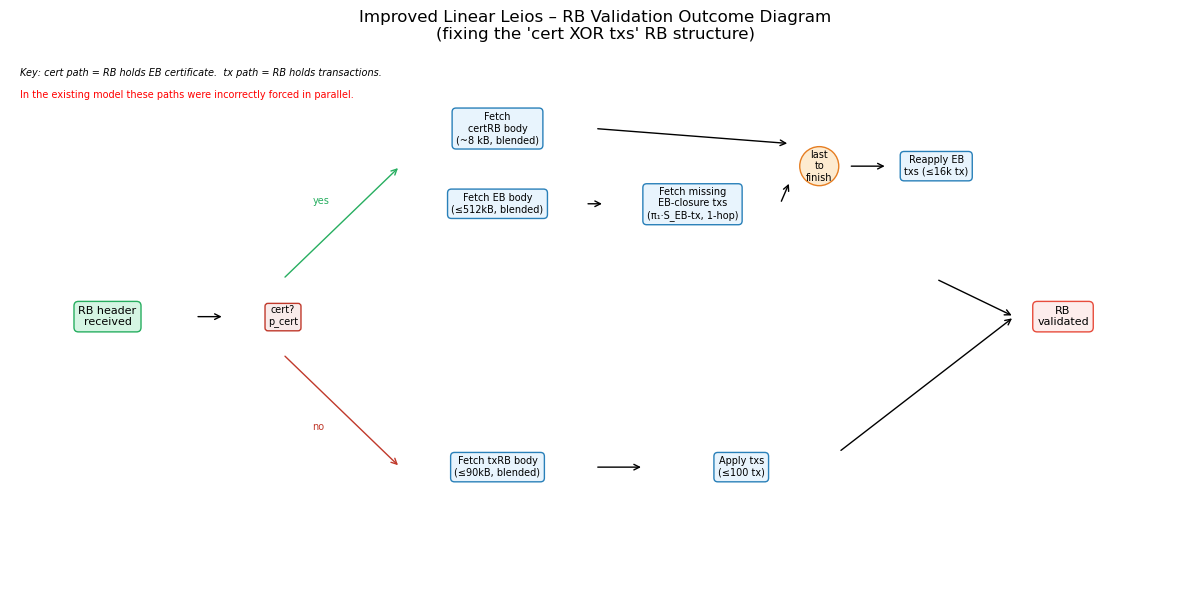

In [22]:
plot_outcome_diagram()


## 6. Comparison with Prior Analysis

| Aspect                      | Prior model                         | Improved model              |
|-----------------------------|-------------------------------------|-----------------------------|
| RB structure                | Both tx + cert paths forced always  | Probabilistic choice p_cert |
| EB closure size (model)     | Implicit; N=2500 hardcoded          | Explicit sweep 0–12 MB      |
| Reapply distribution        | Scale mixture U(1,N): mean N/2 txs  | Fixed-N CLT: exactly N txs  |
| EB closure fetch            | Not modelled (TxCache only)         | 1-hop bulk transfer         |
| Certification probability   | Not computed; assumed fixed         | Computed from quorum model  |
| Per-tx apply time           | 10.60 ms (per-block mean)           | 0.507 ms/tx (tx-weighted)   |
| Per-tx reapply time         | 2.71 ms (per-block mean)            | 0.070 ms/tx (tx-weighted)   |
| Network transfer model      | Empirical Praos table (≤2 MB data)  | TCP slow-start + selectable steady-state (Mathis / CUBIC) |
| P(≤14s) in prior model      | 0.9740 (single point)               | Not directly comparable      |
| P_cert at 12 MB (Mathis)    | Not computed                        | 0.497 (at Praos cap)        |
| P_cert at 12 MB (CUBIC)     | Not computed                        | 0.497 (at Praos cap)        |

## 7. Limitations and Assumptions (abridged)

1. **1-hop approximation** — assumes upstream peer holds the missing
   transactions.  Under total pre-diffusion failure $P_\text{cert} \to 0$
   under both models at 12 MB.
2. **Average tx size 1 kB** — the CIP uses 2 kB in some places (the model is
   robust to this; 2 kB only widens the margin).
3. **Single scalar $\pi_1$** — temporal stickiness in mempool divergence is
   not captured; §5.5 sweeps $\pi_1$ to bound the residual uncertainty.
4. **Fixed binary miss fraction** — no heterogeneity across nodes; a
   cold-mempool node missing 100% of the closure sits well over the deadline
   under Mathis.
5. **No adversarial behaviour** — model assumes honest tx-submission.
6. **TCP throughput model assumptions** — TCP slow start from cwnd₀ = 10 MSS,
   capped at model-specific $W_\text{ss}$; persistent TCP without handshake.
7. **No FFD (Freshest First Delivery).**
8. **Voter deadline = `3·L_hdr + L_vote = 7s`** — if the actual deadline is
   shorter the feasible $S_{EB\text{-}tx}$ shrinks correspondingly.

## 8. Recommendations (abridged)

1. **CIP-0164 12 MB target is robustly feasible** at the empirical
   $\pi_1 \approx 0.06$ and Praos paper's RTT values under both throughput
   models.
2. **CPU is not the binding constraint** at any closure size ≤ 12 MB
   (single-core ceiling ≈ 38 MB).
3. **Ensure effective tx-submission pre-diffusion** — the 1-hop approximation
   is the remaining load-bearing assumption.
4. **The Praos interruption probability (≈ 0.503) is a hard ceiling** —
   $P_\text{cert}$ cannot exceed $\approx 0.497$ whenever quorum is met.
5. **Measure actual network conditions on the SPO mesh** to narrow the
   Mathis-vs-CUBIC band.
6. **Adopt the empirical $\pi_1$ estimate** ($\approx 0.06$ cross-region mean,
   0.085 worst-pair) — see `pi1_derivation.md`.
7. **Verify the average transaction size assumption** (1 kB vs 2 kB only
   widens the margin).
8. **Re-examine per-tx timing constants with a richer dataset** beyond the
   0–385 tx/block empirical range.


## Interactive exploration

Edit the parameters in the cells below and re-run to explore the numbers.
The full sweep (`run_sweep`) re-evaluates the model at the parameters set by
`set_network_model(...)` and `set_cache_miss_rate(...)`.


At model=cubic, π₁=0.06, S_EB_tx=12.00 MB:
  P_validating  = 0.9974
  P_quorum      = 1.0000
  P_interrupted = 0.5034
  P_cert        = 0.4966
  P(≤7s)        = 0.9987
  P(≤14s)       = 1.0000
  Q50           = 1.45 s
  Q95           = 4.27 s
  Q99           = 5.65 s


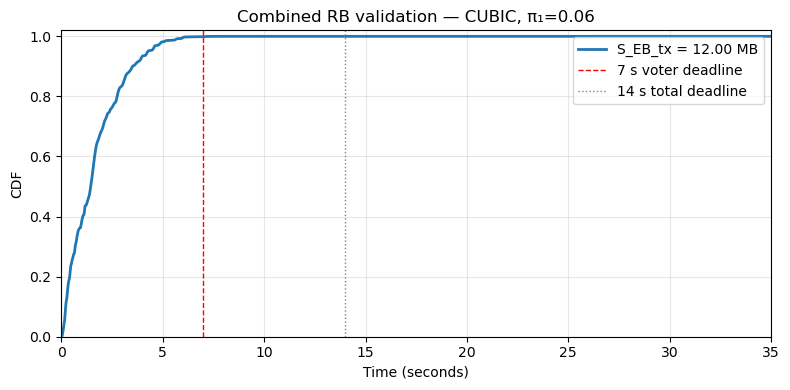

In [23]:
# === edit these and re-run the cell ============================
model = "cubic"   # 'mathis' or 'cubic'
pi1   = 0.06      # TxCache miss rate
s_kb  = 12288     # closure size in kB (use 1024 for 1 MB, 12288 for 12 MB)
# ================================================================

set_network_model(model)
set_cache_miss_rate(pi1)

info = compute_p_certified(s_kb)
cdf  = cdf_validate_rb(info["p_cert"], s_kb)
print(f"At model={model}, π₁={pi1}, S_EB_tx={s_kb/1024:.2f} MB:")
print(f"  P_validating  = {info['p_validating']:.4f}")
print(f"  P_quorum      = {info['p_quorum']:.4f}")
print(f"  P_interrupted = {info['p_interrupted']:.4f}")
print(f"  P_cert        = {info['p_cert']:.4f}")
print(f"  P(≤7s)        = {success_within(cdf, 7.0):.4f}")
print(f"  P(≤14s)       = {success_within(cdf, 14.0):.4f}")
print(f"  Q50           = {quantile_of(cdf, 0.50):.2f} s")
print(f"  Q95           = {quantile_of(cdf, 0.95):.2f} s")
print(f"  Q99           = {quantile_of(cdf, 0.99):.2f} s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TIMES, cdf, lw=2, label=f"S_EB_tx = {s_kb/1024:.2f} MB")
ax.axvline(7.0,  color="red",  ls="--", lw=1, label="7 s voter deadline")
ax.axvline(14.0, color="gray", ls=":",  lw=1, label="14 s total deadline")
ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
ax.set_xlim(0, 35); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(f"Combined RB validation — {model.upper()}, π₁={pi1}")
ax.legend(); fig.tight_layout(); plt.show()

# Reset to defaults for any downstream cells.
set_network_model("mathis"); set_cache_miss_rate(1/6)


## References

- CIP-0164 – Ouroboros Leios
- `analysis/deltaq/linear-leios/docs/report.md` – Prior ΔQ analysis
- `post-cip/apply-reapply/ReadMe.md` – Ledger apply/reapply timing measurements
- `docs/deltaq_PraosModel.pdf` – Praos ΔQ analysis
- Mathis et al. (1997), *The macroscopic behavior of the TCP congestion
  avoidance algorithm*, ACM SIGCOMM CCR.
- Ha, Rhee, Xu (2008), *CUBIC: A new TCP-friendly high-speed TCP variant*,
  ACM SIGOPS Operating Systems Review.  Standardised by RFC 8312.
